In [ ]:
import os
import sys

# Repository root, so that paths.py (DATA_DIR / RESULTS_DIR / FIGURES_DIR) can be imported.
sys.path.insert(0, os.path.abspath('../..'))
import paths

# Norman 2019 — interaction rules and the erythroid axis

K562 is a chronic myeloid leukaemia (CML) blast-crisis line that can be pushed toward erythroid,
megakaryocytic or granulocytic states; Norman et al. describe erythroid, megakaryocyte (CD41⁺) and
granulocyte clusters in this screen. Using the 5 trained SHERLOCK runs from `norman_figure.ipynb`, this
notebook:

1. rebuilds the seven model-parameter descriptors and the rule-based interaction classifier;
2. finds which latent (W) axes carry the erythroid and granulocytic programmes;
3. defines the fate axis from canonical lineage markers and places the modules on it;
4. tests how the positions of a pair's two modules relate to its interaction type.

Only the **measured, labelled panel** is analysed — a curated selection of combinations, so nothing is
extrapolated to unmeasured pairs. Nothing is written to disk. Modules are the consensus modules from
`module_interaction.ipynb`; ground truth is Norman's `genetic_interactions.csv` with the two synergy
classes merged.

In [1]:
import sys, warnings
from pathlib import Path
from itertools import combinations
import numpy as np, pandas as pd, torch, scanpy as sc
import matplotlib as mpl, matplotlib.pyplot as plt, seaborn as sns
from scipy.optimize import linear_sum_assignment
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from scipy.stats import mannwhitneyu
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
warnings.filterwarnings('ignore')
import sherlock as slk

mpl.rcParams.update({'font.size': 8, 'axes.titlesize': 9, 'axes.spines.top': False,
                     'axes.spines.right': False, 'figure.dpi': 150, 'svg.fonttype': 'none'})
N_RUNS, GATE_THR, N_BG = 5, 0.5, 256
FIG = Path(f'{paths.RESULTS_DIR}/norman_figure')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
PALETTE = {'approximately additive': '#4DAF4A', 'epistasis': '#FF7F00', 'neomorphic': '#984EA3',
           'potentiation': '#F781BF', 'redundant': '#A65628', 'suppression': '#E41A1C', 'synergy': '#377EB8'}
CLASSES = list(PALETTE)
short = lambda c: c.replace('approximately additive', 'additive')
NAMES = {'rho': 'parent similarity', 'private_frac': 'private latent factors',
         'c_sum': 'parent scaling', 'syn_rel': 'interaction term size',
         'joint_over_add': 'combination vs sum of parents', 'dom_gap': 'parent dominance',
         'syn_offgate_dec': 'interaction on unused factors'}

# data, with the gene filter the models were trained on
data = sc.read_h5ad(f'{paths.DATA_DIR}/norman/Norman_2019.h5ad')
data.X = data.layers['counts'].copy()
slk.pp.slk_prepare_data(data, pert_key='perturbation_name', ntc_label='control', treatment_key=None, inplace=True)
labels = data.obs[slk.configs.get_config('pert_key')].astype(str).values
NTC = slk.configs.get_config('ntc_label')
genes = sorted({g for l in set(labels) if l != NTC for g in l.split('+')})
g2i = {g: i for i, g in enumerate(genes)}
P = len(genes)
_lib = np.asarray(data.X.sum(1)).ravel()
def _pb(mask):                                      # observed pseudobulk log2 CPM of the current gene set
    return np.log2(np.asarray(data.X[mask].multiply(1e4 / _lib[mask][:, None]).mean(0)).ravel() + 1)

# Observed fate scores from CANONICAL markers, on all genes (before the model's gene filter).
# Per marker: log2 fold change vs NTC for each single perturbation, z-scored across perturbations;
# a fate score is the mean over that fate's markers. CRISPRa targets are never used as markers.
MARKERS = {
    'erythroid': ['HBG1', 'HBG2', 'HBZ', 'HBA1', 'HBA2', 'HBE1', 'HBD', 'GYPA', 'GYPB', 'ALAS2', 'SLC25A37',
                  'TFRC', 'KLF1', 'GATA1', 'EPOR', 'AHSP', 'SLC4A1'],
    'megakaryocytic': ['ITGA2B', 'ITGB3', 'GP9', 'GP1BA', 'GP1BB', 'GP6', 'PF4', 'PPBP', 'VWF', 'TUBB1', 'SELP',
                       'CD9', 'MYL9', 'TREML1', 'F13A1', 'PLEK', 'MPL', 'LTBP1', 'CD36', 'PECAM1'],
    'granulocytic': ['MPO', 'ELANE', 'AZU1', 'PRTN3', 'CTSG', 'LYZ', 'S100A8', 'S100A9', 'CSF3R', 'ITGAM', 'CD33',
                     'MNDA', 'FCGR1A', 'LST1', 'FCER1G', 'CST3', 'CEBPE', 'LGALS3', 'ANXA1', 'SRGN'],
}
FATES = list(MARKERS)
MARKERS = {f: [g for g in gs if g in set(data.var_names) and g not in set(genes)] for f, gs in MARKERS.items()}
_mg = sorted({g for gs in MARKERS.values() for g in gs})
_Xm = data[:, _mg].X.tocsr()
_cpm = lambda mask: np.asarray(_Xm[mask].multiply(1e4 / _lib[mask][:, None]).mean(0)).ravel()
_ntc_m = _cpm(labels == NTC)
_lfc = pd.DataFrame(np.stack([np.log2(_cpm(labels == g) + .05) - np.log2(_ntc_m + .05) for g in genes]),
                    index=genes, columns=_mg)
_z = (_lfc - _lfc.mean()) / (_lfc.std() + 1e-9)
fate = pd.DataFrame({f: _z[gs].mean(1) for f, gs in MARKERS.items()})
_det = np.asarray((_Xm[labels == NTC] > 0).mean(0)).ravel()
print('canonical markers used:', {f: len(gs) for f, gs in MARKERS.items()},
      '| detected in control cells (median):', {f: round(float(np.median(_det[[_mg.index(g) for g in gs]])), 3)
                                                 for f, gs in MARKERS.items()})
data = data[:, (np.asarray(data.X.mean(0)).ravel() > 0.5) | data.var_names.isin(set(genes))].copy()
var = np.array(data.var_names)
readout = ~np.isin(var, genes)                      # exclude CRISPRa targets from any readout
bg_idx = np.random.default_rng(0).choice(np.where(labels == NTC)[0], N_BG, replace=False)
x_bg = torch.tensor(data.X[bg_idx].toarray(), dtype=torch.float32, device=DEVICE)

# learned rho (5 runs), consensus modules, ground truth
_m = np.load(FIG / 'run_matrices.npz')
R = np.mean([(_m[f'rho_corr_{k}'] + _m[f'rho_corr_{k}'].T) / 2 for k in range(1, N_RUNS + 1)], 0)
module = pd.read_csv(f'{paths.RESULTS_DIR}/module_interaction/consensus_modules.csv', index_col=0)['module']
MODULES = sorted(module.unique(), key=lambda m: int(m[1:]))
gi = pd.read_csv(f'{paths.DATA_DIR}/norman/genetic_interactions.csv')
gi['combination'] = gi['combination'].map(lambda s: '+'.join(sorted(s.split('+'))))
gi['gi'] = gi['genetic_interaction'].str.strip().replace({'synergy (dissimilar phenotype)': 'synergy',
                                                          'synergy (similar phenotype)': 'synergy'})
gi = gi[gi['combination'].map(lambda c: all(g in g2i for g in c.split('+')))].reset_index(drop=True)
print(f'{P} perturbations, {readout.sum()} readout genes, {len(gi)} labelled pairs, {len(MODULES)} modules')

canonical markers used: {'erythroid': 15, 'megakaryocytic': 12, 'granulocytic': 16} | detected in control cells (median): {'erythroid': 0.728, 'megakaryocytic': 0.011, 'granulocytic': 0.028}


105 perturbations, 3168 readout genes, 86 labelled pairs, 12 modules


## 1. Seven descriptors from the model's parameters

Computed for the labelled pairs only. The combined latent state is
**z_ab = z₀ + c_a·S_a + c_b·S_b + syn(ρ_a, ρ_b)** with S = A⊙W.

| Descriptor | From | Meaning |
|---|---|---|
| `rho` | covariance Σ_P | do the two perturbations act in the same direction? |
| `private_frac` | gates W, A⊙W | share of each shift on factors the partner does not gate |
| `c_sum` | parent-scale layer | c_a + c_b: damped (< 2) or amplified |
| `syn_rel` | synergy MLP | ‖syn‖ / ‖S_a + S_b‖ — how big the synergy term is |
| `joint_over_add` | decoder | ‖decoded combination‖ / ‖D_a + D_b‖ |
| `dom_gap` | decoder | \|cos(combination, D_a) − cos(combination, D_b)\| — dominance |
| `syn_offgate_dec` | syn × W × decoder | decoded effect of syn on factors **neither** parent gates — where it acts |

In [2]:
lab = gi[['combination', 'gi', 'genetic_interaction']].copy()
lab['a'] = lab['combination'].str.split('+').str[0]
lab['b'] = lab['combination'].str.split('+').str[1]
IA, IB = lab['a'].map(g2i).values, lab['b'].map(g2i).values
DESC = ['private_frac', 'c_sum', 'syn_rel', 'joint_over_add', 'dom_gap', 'syn_offgate_dec']
runs = []
for run in range(1, N_RUNS + 1):
    m = slk.tl.load_results(FIG / 'models' / f'run_{run}.pth').to(DEVICE)
    with torch.no_grad():
        sh = m._get_all_pert_shifts(DEVICE)[1:]
        S, W, q = sh[:, 0], sh[:, 1], sh[:, 2]
        u = m._abduct_ntc(x_bg)
        ln = lambda z: torch.log1p(m._decode_to_expr(z, 1.) * 1e4)
        def dec(shift):                                            # (b, d) -> (b, G), mean over backgrounds
            z = (u[None] + shift[:, None]).reshape(-1, u.shape[-1])
            return ln(z).reshape(shift.shape[0], N_BG, -1).mean(1)
        base = ln(u).mean(0)
        D = dec(S) - base                                          # single-perturbation effects
        act = W > GATE_THR
        delta = float(S.abs()[act].median())                       # decoded signature of each latent factor
        E = torch.eye(m.latent_dim, device=DEVICE) * delta
        V = ((dec(E) - dec(-E)) / 2).cpu().numpy()
        a = torch.as_tensor(IA, device=DEVICE); b = torch.as_tensor(IB, device=DEVICE)
        ca, cb = m._parent_scales_from_rho(q[a], q[b])
        syn = m._synergy_shift_from_rho(q[a], q[b])
        lin = ca * S[a] + cb * S[b]
        g_lin = dec(lin)
        d_ab = dec(lin + syn) - base
        off = ~(act[a] | act[b])
        add = D[a] + D[b]; addn = add.norm(dim=1) + 1e-8
        cos = lambda x, y: (x * y).sum(1) / (x.norm(dim=1) * y.norm(dim=1) + 1e-8)
        pa = ((~act[b]) * S[a] ** 2).sum(1) / ((S[a] ** 2).sum(1) + 1e-8)
        pb = ((~act[a]) * S[b] ** 2).sum(1) / ((S[b] ** 2).sum(1) + 1e-8)
        desc = {'private_frac': (pa + pb) / 2, 'c_sum': (ca + cb).squeeze(-1),
                'syn_rel': syn.norm(dim=1) / ((S[a] + S[b]).norm(dim=1) + 1e-8),
                'joint_over_add': d_ab.norm(dim=1) / addn,
                'dom_gap': (cos(d_ab, D[a]) - cos(d_ab, D[b])).abs(),
                'syn_offgate_dec': (dec(lin + syn * off) - g_lin).norm(dim=1) / addn}
        runs.append({'desc': pd.DataFrame({k: v.cpu().numpy() for k, v in desc.items()}),
                     'D': D.cpu().numpy(), 'S': S.cpu().numpy(), 'W': W.cpu().numpy(), 'V': V})
    del m; torch.cuda.empty_cache()

for k in DESC:
    lab[k] = np.mean([r['desc'][k].values for r in runs], 0)
lab['rho'] = R[IA, IB]
lab['module_a'] = lab['a'].map(module); lab['module_b'] = lab['b'].map(module)
DESC7 = ['rho'] + DESC
print(f'descriptors computed for the {len(lab)} labelled pairs')

descriptors computed for the 86 labelled pairs


## 2. Rule-based classification

A decision list, applied top to bottom; unclaimed pairs are called additive. The cut points are the
fixed values found by rule mining in `module_interaction.ipynb`.

Rule-based classifier on 86 labelled pairs: accuracy 0.767, balanced 0.781
  additive    : c_sum <= 1.88  AND  syn_rel <= 0.173
  redundant   : rho > 0.36  AND  joint_over_add <= 0.966
  synergy     : rho > 0.36  AND  joint_over_add > 1.1
  potentiation: private_frac > 0.249  AND  c_sum > 1.5
  epistasis   : joint_over_add <= 1.03  AND  dom_gap > 0.643
  suppression : rho <= 0.135  AND  joint_over_add <= 1.14
  neomorphic  : syn_offgate_dec > 0.0649  AND  rho <= 0.326


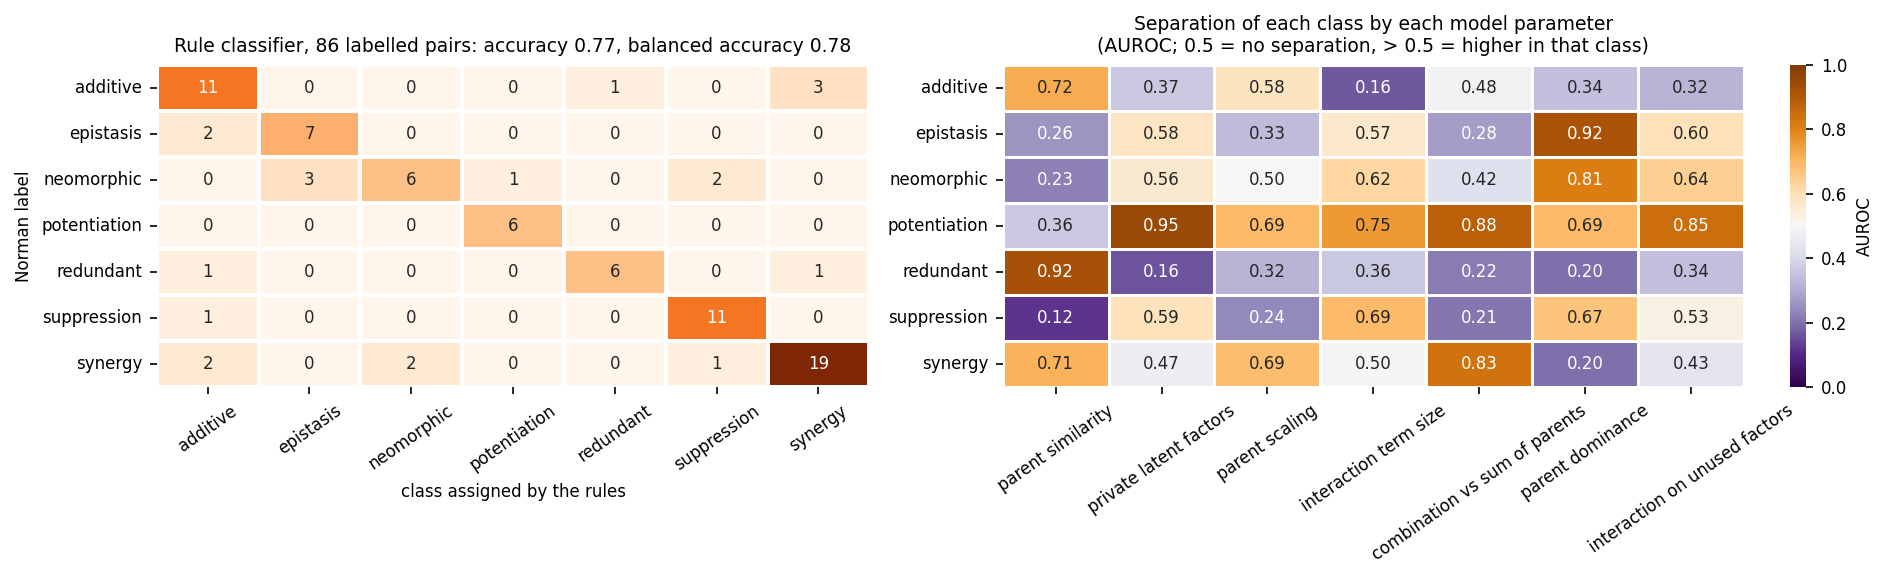

In [3]:
RULES = [  # (class, [(descriptor, op, threshold)])
    ('approximately additive', [('c_sum', '<=', 1.8769652366638183), ('syn_rel', '<=', 0.1731259450316429)]),
    ('redundant',    [('rho', '>', 0.36017714440822585), ('joint_over_add', '<=', 0.9664641320705414)]),
    ('synergy',      [('rho', '>', 0.36017714440822585), ('joint_over_add', '>', 1.1006439685821534)]),
    ('potentiation', [('private_frac', '>', 0.24869043231010438), ('c_sum', '>', 1.502985668182373)]),
    ('epistasis',    [('joint_over_add', '<=', 1.0306628942489624), ('dom_gap', '>', 0.6432075917720794)]),
    ('suppression',  [('rho', '<=', 0.13503594752401113), ('joint_over_add', '<=', 1.1355479955673218)]),
    ('neomorphic',   [('syn_offgate_dec', '>', 0.06492092683911324), ('rho', '<=', 0.3258450113236904)]),
]

def classify(df):
    pred = np.array(['approximately additive'] * len(df), dtype=object)
    free = np.ones(len(df), bool)
    for cls, conds in RULES:
        hit = free.copy()
        for f, op, thr in conds:
            hit &= (df[f] > thr).values if op == '>' else (df[f] <= thr).values
        pred[hit] = cls; free &= ~hit
    return pred

lab['rule_class'] = classify(lab)
acc = np.mean(lab['rule_class'] == lab['gi']); bal = balanced_accuracy_score(lab['gi'], lab['rule_class'])
print(f'Rule-based classifier on {len(lab)} labelled pairs: accuracy {acc:.3f}, balanced {bal:.3f}')
for cls, conds in RULES:
    print(f"  {short(cls):12s}: " + '  AND  '.join(f'{f} {op} {thr:.3g}' for f, op, thr in conds))

auc = pd.DataFrame({f: {c: mannwhitneyu(lab.loc[lab.gi == c, f], lab.loc[lab.gi != c, f]).statistic /
                        ((lab.gi == c).sum() * (lab.gi != c).sum()) for c in CLASSES} for f in DESC7})
fig, ax = plt.subplots(1, 2, figsize=(13, 3.9), gridspec_kw={'width_ratios': [1, 1.3]})
sns.heatmap(confusion_matrix(lab['gi'], lab['rule_class'], labels=CLASSES), annot=True, fmt='d', cmap='Oranges',
            cbar=False, linewidths=1, linecolor='white', ax=ax[0],
            xticklabels=[short(c) for c in CLASSES], yticklabels=[short(c) for c in CLASSES])
ax[0].set(xlabel='class assigned by the rules', ylabel='Norman label',
          title=f'Rule classifier, 86 labelled pairs: accuracy {acc:.2f}, balanced accuracy {bal:.2f}')
sns.heatmap(auc.rename(columns=NAMES), annot=True, fmt='.2f', cmap='PuOr_r', center=.5, vmin=0, vmax=1, linewidths=.5,
            linecolor='white', ax=ax[1], yticklabels=[short(c) for c in CLASSES], cbar_kws={'label': 'AUROC'})
ax[1].set_title('Separation of each class by each model parameter\n(AUROC; 0.5 = no separation, > 0.5 = higher in that class)')
for a_ in ax:
    a_.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()

## 3. Which W axes carry the erythroid and granulocytic programmes?

Each latent factor's decoded signature (the expression change from moving along that axis) is matched
across runs (Hungarian assignment on |cos|, sign-corrected) and scored on two programmes, using only
canonical markers the model decodes:

- **erythroid** — globins, glycophorins, haem synthesis, GATA1, NFE2, TFRC (20 genes);
- **granulocytic** — CD33, LST1, FCER1G, CST3 (the only decodable canonical granulocyte markers).

Canonical megakaryocytic markers (ITGA2B/CD41, ITGB3, GP9, PF4, …) are all below the model's gene
filter, so megakaryocytic priming is assessed from the observed data in section 4, not from model axes.

In [4]:
ERY = ['HBG1', 'HBG2', 'HBZ', 'HBA1', 'HBE1', 'HBD', 'HBQ1', 'GYPA', 'GYPB', 'GYPC', 'ALAS2', 'HMBS', 'UROD',
       'BLVRB', 'SLC25A37', 'GATA1', 'NFE2', 'TFRC', 'ANK1', 'PRDX2']
GRAN = [g for g in MARKERS['granulocytic'] if g in set(var[readout])]
PROGS = {'erythroid': np.isin(var, ERY) & readout, 'granulocytic': np.isin(var, GRAN) & readout}
P2 = list(PROGS)
print('decodable programme genes:', {k: int(v.sum()) for k, v in PROGS.items()}, '| granulocytic:', GRAN)
def prog_score(M):                                  # gene-space rows -> programme scores (per-row z units)
    sd = M[:, readout].std(1) + 1e-9
    return pd.DataFrame({k: M[:, msk].mean(1) / sd for k, msk in PROGS.items()})

nrm = lambda X: X[:, readout] / (np.linalg.norm(X[:, readout], axis=1, keepdims=True) + 1e-9)
L = runs[0]['V'].shape[0]
perm, sign, match = [np.arange(L)], [np.ones(L)], []
for r in runs[1:]:
    C = nrm(runs[0]['V']) @ nrm(r['V']).T
    ri, ci = linear_sum_assignment(-np.abs(C))
    perm.append(ci); sign.append(np.sign(C[ri, ci])); match.append(np.abs(C[ri, ci]))
V_al = np.stack([r['V'][p] * sg[:, None] for r, p, sg in zip(runs, perm, sign)])
S_al = np.stack([r['S'][:, p] * sg for r, p, sg in zip(runs, perm, sign)])
W_al = np.stack([r['W'][:, p] for r, p in zip(runs, perm)])

per_run = [prog_score(V) for V in V_al]
fac = sum(per_run) / N_RUNS
fac.index = [f'F{k}' for k in range(L)]
for p_ in P2:
    fac[f'sd_{p_}'] = np.std([s_[p_] for s_ in per_run], 0)
fac['cross-run similarity'] = np.mean(match, 0)
fac['similarity sd'] = np.std(match, 0)
_nuse = (W_al > GATE_THR).sum(1)                    # perturbations using each factor, per run
fac['perts using'] = _nuse.mean(0)
fac['perts using sd'] = _nuse.std(0)
used = fac['perts using'] >= 1
dom = fac[P2].abs().idxmax(1)
val = fac[P2].to_numpy()[np.arange(L), [P2.index(d) for d in dom]]
fac['call'] = np.where(~used, 'unused', np.where(np.abs(val) < 0.5, 'none', dom + np.where(val > 0, ' +', ' −')))
load = pd.DataFrame(S_al.mean(0), index=genes, columns=fac.index)
fac['drives +'] = [', '.join(load[f].nlargest(4).index) for f in fac.index]
fac['drives −'] = [', '.join(load[f].nsmallest(4).index) for f in fac.index]
print(f"{(~used).sum()} of {L} latent factors are used by no perturbation and are excluded: {', '.join(fac.index[~used])}")
fac[used].sort_values('erythroid', ascending=False)[P2 + ['cross-run similarity', 'similarity sd',
    'perts using', 'perts using sd', 'call', 'drives +', 'drives −']].round(2)

decodable programme genes: {'erythroid': 20, 'granulocytic': 4} | granulocytic: ['CD33', 'LST1', 'FCER1G', 'CST3']
3 of 16 latent factors are used by no perturbation and are excluded: F1, F8, F14


,erythroid,granulocytic,cross-run similarity,similarity sd,perts using,perts using sd,call,drives +,drives −
F13,5.08,-0.21,0.86,0.08,86.8,5.04,erythroid +,"IKZF3, DUSP9, TP73, PRDM1","CEBPA, CEBPE, OSR2, CEBPB"
F5,2.84,0.42,0.78,0.07,52.6,12.66,erythroid +,"FEV, ELMSAN1, IKZF3, LHX1","DUSP9, ZBTB10, COL2A1, DLX2"
F11,0.53,0.96,0.81,0.12,77.4,27.43,granulocytic +,"COL1A1, CEBPA, TP73, COL2A1","ZC3HAV1, MAP2K3, CSRNP1, MAP2K6"
F4,0.44,-0.02,0.97,0.02,88.8,7.39,none,"MAP2K3, MAP2K6, MAP7D1, SLC38A2","TP73, SPI1, HOXA13, HNF4A"
F9,0.31,0.29,0.86,0.13,37.2,22.52,none,"PRDM1, DUSP9, ATL1, IER5L","KLF1, MAP2K3, OSR2, ELMSAN1"
F0,0.24,0.44,0.95,0.02,47.4,11.67,none,"TP73, SPI1, CEBPA, HOXA13","ZC3HAV1, SLC38A2, DUSP9, SLC4A1"
F3,0.13,0.88,0.60,0.14,4.6,8.24,granulocytic +,"OSR2, TBX3, TP73, CEBPB","RHOXF2, CNN1, HOXC13, HOXA13"
F2,-0.36,-0.33,0.76,0.21,38.2,4.79,none,"NIT1, RHOXF2, HOXA13, LHX1","KLF1, COL2A1, COL1A1, ZC3HAV1"
F10,-0.92,-0.29,0.75,0.18,60.6,8.87,erythroid −,"TBX2, LHX1, SPI1, FEV","KLF1, OSR2, PRTG, SLC4A1"
F15,-1.21,-0.33,0.60,0.11,66.0,7.95,erythroid −,"SET, IRF1, TBX2, TBX3","MAPK1, ETS2, IGDCC3, IKZF3"


### Can the latent axes be matched across runs?

Latent dimensions are arbitrary within a run, so the axis names above rely on matching. **(a)** For
runs 2–5, the |cosine| between every run-1 axis signature and every signature of that run, with columns
reordered by the matching: a bright, clean diagonal means each axis has one clear counterpart.
**(b)** For every axis, the |cosine| of its match in each run (dots), the best alternative in the same run
(grey ×), and the range of |cosine| between unmatched axes (shaded; 95th percentile marked). Unused axes
are shown in grey. The permutation test compares the total matched |cosine| with 5,000 random pairings.

Unmatched pairs: median |cos| 0.09, 95th percentile 0.41
Total matched |cos| vs random pairings, per run: run 2: p = 0.0002, run 3: p = 0.0002, run 4: p = 0.0002, run 5: p = 0.0002


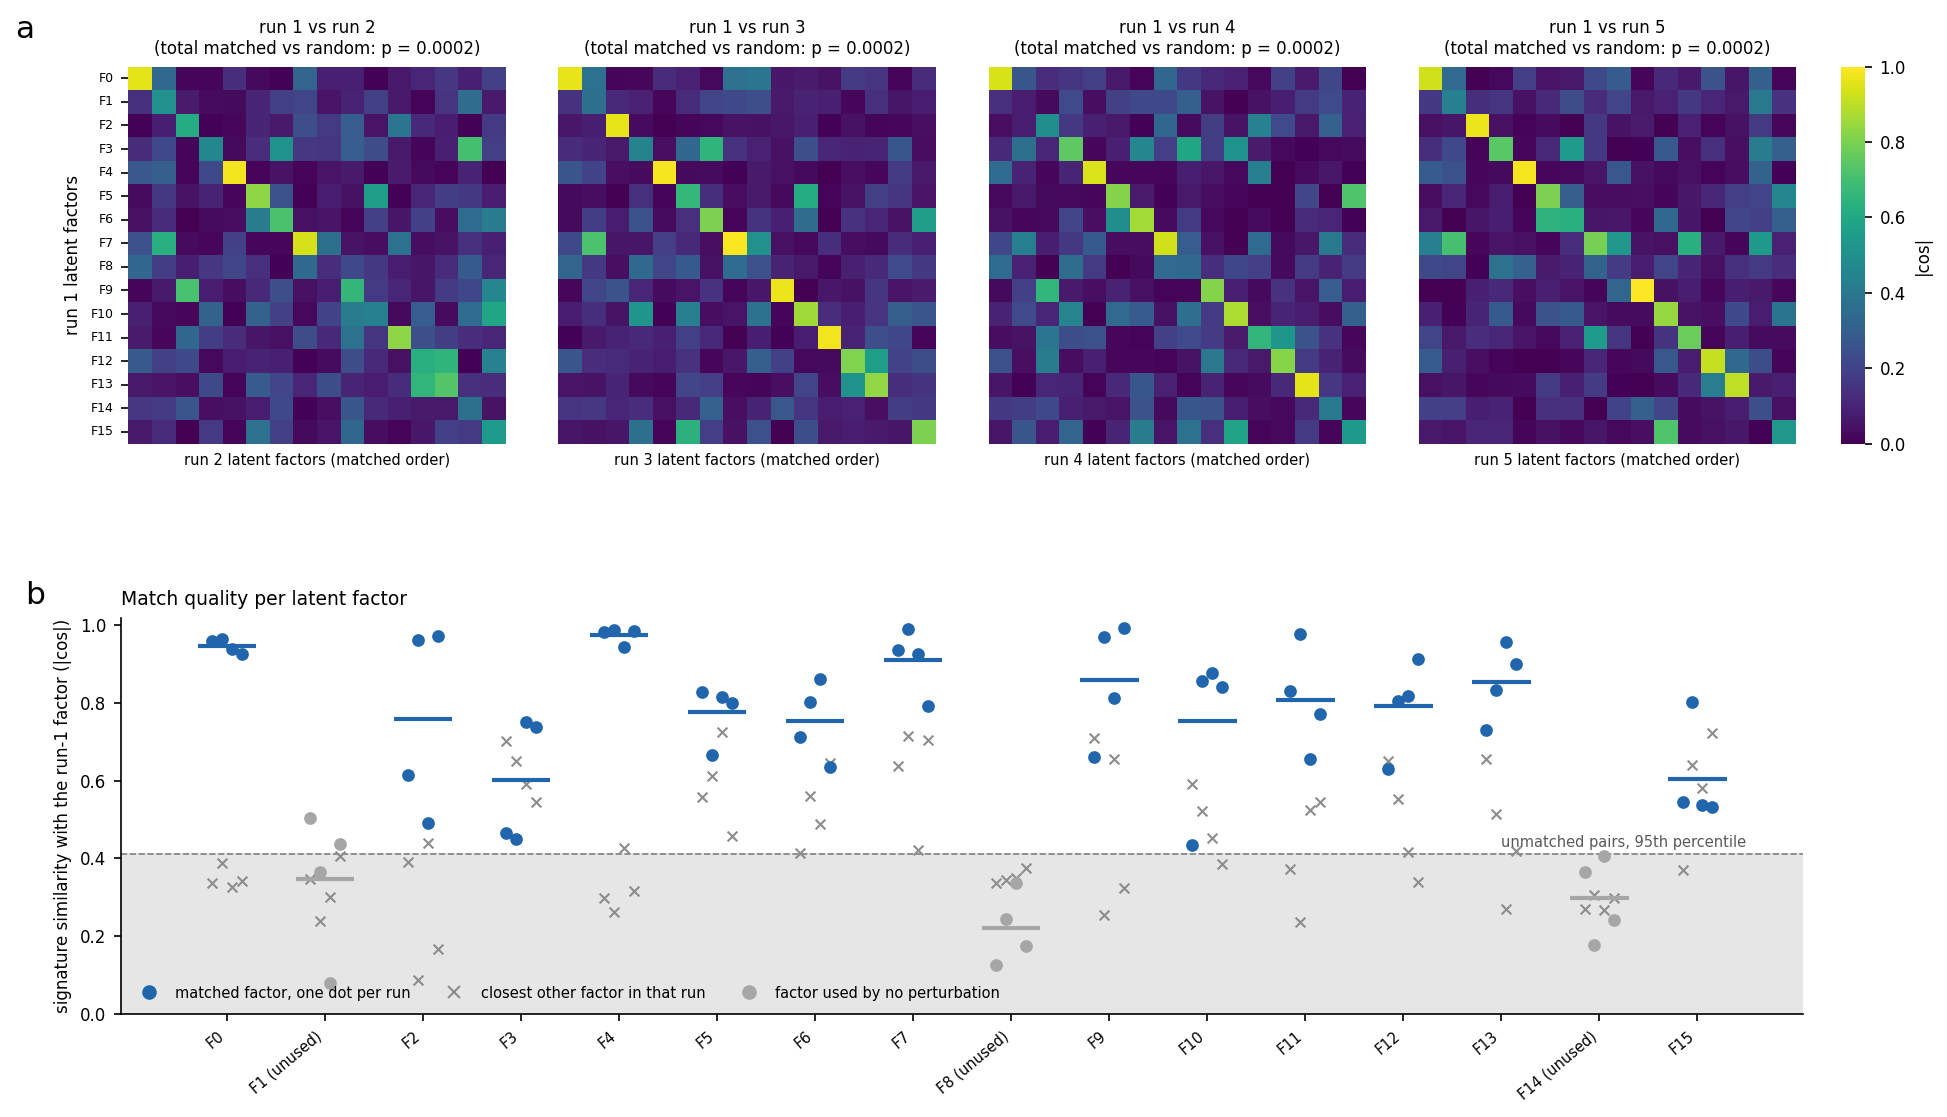

,mean matched |cos|,lowest matched |cos|,mean best alternative,mean margin,runs above null 95th pct,used
F0,0.95,0.93,0.35,0.60,4,True
F1,0.35,0.08,0.32,0.02,2,False
F2,0.76,0.49,0.27,0.49,4,True
F3,0.60,0.45,0.62,-0.02,4,True
F4,0.97,0.94,0.33,0.65,4,True
F5,0.78,0.67,0.59,0.19,4,True
F6,0.75,0.64,0.53,0.23,4,True
F7,0.91,0.79,0.62,0.29,4,True
F8,0.22,0.13,0.35,-0.13,0,False
F9,0.86,0.66,0.49,0.37,4,True


In [5]:
Cs = []
for r, p_ in zip(runs[1:], perm[1:]):
    Cs.append(np.abs(nrm(runs[0]['V']) @ nrm(r['V']).T)[:, p_])     # matched partners on the diagonal
eye = np.eye(L, dtype=bool)
diag = np.stack([np.diag(Cm) for Cm in Cs])                          # (runs 2-5, axes)
runner = np.stack([np.where(eye, -1, Cm).max(1) for Cm in Cs])       # best alternative for each run-1 axis
offd = np.concatenate([Cm[~eye] for Cm in Cs])
null95 = np.quantile(offd, .95)
rng_m = np.random.default_rng(0)
perm_p = []
for Cm in Cs:
    tot = np.trace(Cm)
    null_tot = np.array([Cm[np.arange(L), rng_m.permutation(L)].sum() for _ in range(5000)])
    perm_p.append((np.sum(null_tot >= tot) + 1) / 5001)
match_tab = pd.DataFrame({'mean matched |cos|': diag.mean(0), 'lowest matched |cos|': diag.min(0),
                          'mean best alternative': runner.mean(0), 'mean margin': (diag - runner).mean(0),
                          'runs above null 95th pct': (diag > null95).sum(0), 'used': used.values},
                         index=fac.index)
print(f'Unmatched pairs: median |cos| {np.median(offd):.2f}, 95th percentile {null95:.2f}')
print('Total matched |cos| vs random pairings, per run:',
      ', '.join(f'run {k + 2}: p = {pv:.4f}' for k, pv in enumerate(perm_p)))

fig = plt.figure(figsize=(15, 8.2))
gsm = fig.add_gridspec(2, 5, height_ratios=[1, 1.05], width_ratios=[1, 1, 1, 1, .06], hspace=.45, wspace=.12)
cax = fig.add_subplot(gsm[0, 4])
for k, Cm in enumerate(Cs):
    axm = fig.add_subplot(gsm[0, k])
    sns.heatmap(Cm, cmap='viridis', vmin=0, vmax=1, square=True, cbar=k == len(Cs) - 1, ax=axm,
                cbar_ax=cax if k == len(Cs) - 1 else None,
                xticklabels=False, yticklabels=list(fac.index) if k == 0 else False,
                cbar_kws={'label': '|cos|'} if k == len(Cs) - 1 else None)
    axm.set_title(f'run 1 vs run {k + 2}\n(total matched vs random: p = {perm_p[k]:.4f})', fontsize=8)
    axm.set_xlabel(f'run {k + 2} latent factors (matched order)', fontsize=7)
    axm.tick_params(axis='y', labelsize=6)
fig.axes[1].set_ylabel('run 1 latent factors', fontsize=8)
axb = fig.add_subplot(gsm[1, :4])
xs = np.arange(L)
axb.axhspan(offd.min(), null95, color='0.9', zorder=0)
axb.axhline(null95, color='0.5', ls='--', lw=.8)
axb.text(L - .5, null95 + .01, 'unmatched pairs, 95th percentile', ha='right', va='bottom', fontsize=7, color='0.35')
for j in range(L):
    col = '#2166ac' if used.iloc[j] else '0.65'
    axb.scatter(np.full(diag.shape[0], j) + np.linspace(-.15, .15, diag.shape[0]), diag[:, j], s=26, color=col, zorder=3)
    axb.scatter(np.full(diag.shape[0], j) + np.linspace(-.15, .15, diag.shape[0]), runner[:, j], s=22, marker='x',
                color='0.55', lw=1, zorder=2)
    axb.hlines(diag[:, j].mean(), j - .3, j + .3, color=col, lw=2, zorder=4)
axb.set_xticks(xs)
axb.set_xticklabels([f"{f}{'' if u else ' (unused)'}" for f, u in zip(fac.index, used)], rotation=40, ha='right', fontsize=7)
axb.set_ylim(0, 1.02); axb.set_ylabel('signature similarity with the run-1 factor (|cos|)')
axb.legend(handles=[mpl.lines.Line2D([], [], marker='o', ls='', color='#2166ac', label='matched factor, one dot per run'),
                    mpl.lines.Line2D([], [], marker='x', ls='', color='0.55', label='closest other factor in that run'),
                    mpl.lines.Line2D([], [], marker='o', ls='', color='0.65', label='factor used by no perturbation')],
           frameon=False, fontsize=7, loc='lower left', ncol=3)
axb.set_title('Match quality per latent factor', fontsize=9, loc='left')
axb.text(-0.045, 1.02, 'b', transform=axb.transAxes, fontsize=15, va='bottom', ha='right')
fig.axes[1].text(-0.25, 1.06, 'a', transform=fig.axes[1].transAxes, fontsize=15, va='bottom', ha='right')
plt.show()
match_tab.round(2)

## 4. Defining the fate axis

Each perturbation gets an **observed** fate score per lineage from canonical markers (section 1 setup).
These give the axis a biological definition:

- **erythroid programme up vs down** is the main axis; the model's decoded erythroid score agrees with it;
- **megakaryocytic** priming (canonical markers) is examined separately, because it does not oppose
  the erythroid programme in K562. It is a **weak signal**: its markers are detected in ~1% of control
  cells and are absent from the model's genes, so the code below checks that the score is reproducible
  (split-half reliability) and puts a confidence interval on its relation to the erythroid score;
- **granulocytic** priming is what opposes it.

Modules are assigned to a **pole** by their members' mean observed erythroid score: *erythroid up*
(> +0.2), *erythroid down* (< −0.2) or *neutral*. Within the *down* pole, a module is called
*granulocytic* if its granulocytic score exceeds 0.5; within the *up* pole, *erythroid + megakaryocytic*
if its megakaryocytic score exceeds 0.3.

In [6]:
from scipy.stats import pearsonr, spearmanr, fisher_exact
print('Observed canonical fate scores: correlation across the 105 single perturbations')
print(fate.corr().round(2).to_string())

# How trustworthy is each score? Split every perturbation's cells (and the controls) into two random halves,
# score each half separately, and correlate the halves across perturbations (10 random splits).
rng_f = np.random.default_rng(0)
def _fate_scores(rows_by_label):
    ntc_ = _cpm(rows_by_label[NTC])
    lf = pd.DataFrame(np.stack([np.log2(_cpm(rows_by_label[g]) + .05) - np.log2(ntc_ + .05) for g in genes]),
                      index=genes, columns=_mg)
    zz = (lf - lf.mean()) / (lf.std() + 1e-9)
    return pd.DataFrame({f: zz[gs].mean(1) for f, gs in MARKERS.items()})
_rows = {g: np.where(labels == g)[0] for g in genes + [NTC]}
half_r = {f: [] for f in FATES}
for _ in range(10):
    split = {g: rng_f.permutation(ix) for g, ix in _rows.items()}
    h1 = _fate_scores({g: ix[: len(ix) // 2] for g, ix in split.items()})
    h2 = _fate_scores({g: ix[len(ix) // 2:] for g, ix in split.items()})
    for f in FATES:
        half_r[f].append(pearsonr(h1[f], h2[f])[0])
rel = pd.DataFrame({'split-half r': {f: np.mean(v) for f, v in half_r.items()}})
rel['full-data reliability'] = 2 * rel['split-half r'] / (1 + rel['split-half r'])     # Spearman-Brown
print('\nScore reliability:'); print(rel.round(2).to_string())

x_, y_ = fate['erythroid'].values, fate['megakaryocytic'].values
r_em = pearsonr(x_, y_)[0]
boot = [pearsonr(x_[i], y_[i])[0] for i in rng_f.integers(0, len(x_), (5000, len(x_)))]
permr = np.array([pearsonr(x_, rng_f.permutation(y_))[0] for _ in range(5000)])
keep = fate.index != 'FEV'
print(f"\nErythroid vs megakaryocytic: r = {r_em:.2f}, 95% CI [{np.quantile(boot, .025):.2f}, "
      f"{np.quantile(boot, .975):.2f}], permutation p = {(np.sum(np.abs(permr) >= abs(r_em)) + 1) / 5001:.4f}; "
      f"without FEV r = {pearsonr(x_[keep], y_[keep])[0]:.2f}")

D_mean = np.mean([r['D'] for r in runs], 0)
pert = prog_score(D_mean); pert.index = genes
print(f"\nModel-decoded vs observed erythroid score: r = {pearsonr(pert['erythroid'], fate['erythroid'])[0]:.2f}"
      f" (Spearman {spearmanr(pert['erythroid'], fate['erythroid'])[0]:.2f})")

NORMAN = {'erythroid': ['CBL', 'CNN1', 'UBASH3A', 'UBASH3B', 'PTPN9', 'PTPN12'],
          'granulocyte': ['CEBPA', 'CEBPB', 'CEBPE', 'SPI1'],
          'G1 arrest': ['CDKN1A', 'CDKN1B', 'CDKN1C']}
print('\nNorman’s named groups (observed fate scores, mean over members):')
print(pd.DataFrame({k: fate.loc[v].mean() for k, v in NORMAN.items()}).T.round(2).to_string())
print('\nStrongest canonical megakaryocytic priming (Norman’s CD41⁺ group has no named members):')
print(fate.sort_values('megakaryocytic', ascending=False).head(6).round(2).to_string())

mods = fate.groupby(module.reindex(genes).values).mean().reindex(MODULES)
mods['decoded erythroid'] = pert.groupby(module.reindex(genes).values)['erythroid'].mean()
mods['n'] = module.value_counts().reindex(MODULES)
mods['pole'] = np.select([mods['erythroid'] > .2, mods['erythroid'] < -.2], ['erythroid up', 'erythroid down'], 'neutral')
mods['identity'] = np.select(
    [(mods['pole'] == 'erythroid down') & (mods['granulocytic'] > .5), mods['pole'] == 'erythroid down',
     (mods['pole'] == 'erythroid up') & (mods['megakaryocytic'] > .3), mods['pole'] == 'erythroid up'],
    ['granulocytic', 'erythroid repressed only', 'erythroid + megakaryocytic', 'erythroid'], 'neutral')
for k, v in NORMAN.items():
    mods[f'Norman {k}'] = [', '.join(sorted(set(module.index[module == m]) & set(v))) for m in MODULES]
s6_groups = {}
for df in pd.read_excel(Path(paths.DATA_DIR) / 'norman' / 'aax4438_tables6.xlsx', sheet_name=None, header=None).values():
    rows = df.values.tolist()
    for i, rr in enumerate(rows[:-1]):
        if str(rr[0]).strip().isdigit():
            s6_groups[str(rr[1]).strip()] = [g.strip() for g in str(rows[i + 1][0]).split(',')]
mods['Norman Table S6 clusters (≥ 2 members)'] = [
    '; '.join(sorted({lbl for lbl, gs in s6_groups.items() if len(set(gs) & set(module.index[module == m])) >= 2}))
    for m in MODULES]
mods['members'] = [', '.join(module.index[module == m]) for m in MODULES]
pd.set_option('display.max_colwidth', 80)
mods.sort_values('erythroid', ascending=False).round(2)

Observed canonical fate scores: correlation across the 105 single perturbations
                erythroid  megakaryocytic  granulocytic
erythroid            1.00            0.29         -0.31
megakaryocytic       0.29            1.00          0.35
granulocytic        -0.31            0.35          1.00



Score reliability:
                split-half r  full-data reliability
erythroid               0.97                   0.99
megakaryocytic          0.72                   0.84
granulocytic            0.94                   0.97



Erythroid vs megakaryocytic: r = 0.29, 95% CI [0.04, 0.50], permutation p = 0.0054; without FEV r = 0.27

Model-decoded vs observed erythroid score: r = 0.80 (Spearman 0.87)

Norman’s named groups (observed fate scores, mean over members):
             erythroid  megakaryocytic  granulocytic
erythroid         0.39           -0.08         -0.48
granulocyte      -0.81            0.47          2.37
G1 arrest         0.65            0.06         -0.18

Strongest canonical megakaryocytic priming (Norman’s CD41⁺ group has no named members):
        erythroid  megakaryocytic  granulocytic
FEV          1.01            2.70         -0.53
TP73         1.56            1.22          0.43
CEBPA       -1.41            1.20          4.61
HNF4A       -0.32            0.97         -0.33
ZBTB10      -0.29            0.90          0.44
IKZF3        3.13            0.89         -0.11


,erythroid,megakaryocytic,granulocytic,decoded erythroid,n,pole,identity,Norman erythroid,Norman granulocyte,Norman G1 arrest,Norman Table S6 clusters (≥ 2 members),members
M5,0.85,0.50,-0.19,3.30,10,erythroid up,erythroid + megakaryocytic,,,,Homeobox TF; Regulation of apoptosis,"CNNM4, EGR1, FEV, IER5L, IKZF3, LHX1, MEIS1, POU3F2, PRDM1, ZBTB1"
M11,0.39,-0.18,-0.29,3.71,4,erythroid up,erythroid,,,,Ig domain containing,"IGDCC3, PRTG, SLC6A9, TGFBR2"
M7,0.38,-0.03,-0.19,1.90,8,erythroid up,erythroid,,,"CDKN1A, CDKN1B, CDKN1C",Blood coagulation; CDK inhibitor,"ARID1A, CDKN1A, CDKN1B, CDKN1C, IRF1, S1PR2, SET, ZNF318"
M2,0.36,0.00,-0.29,2.70,14,erythroid up,erythroid,"CNN1, PTPN12, PTPN9, UBASH3B",,,Erythrocytosis; RTK binding; Regulation of apoptosis; Tyrosine phosphatase; ...,"CKS1B, CNN1, FOXO4, GLB1L2, HK2, HNF4A, PTPN1, PTPN12, PTPN9, RHOXF2, RREB1,..."
M1,0.25,0.08,-0.06,2.48,18,erythroid up,erythroid,CBL,,,DNA binding; Forkhead TF; Homeobox TF; MAP4K; N-terminal Forkhead TF; N-term...,"AHR, ARRDC3, ATL1, BPGM, C19orf26, CBL, CLDN6, DUSP9, FOXA1, FOXA3, HOXA13, ..."
M4,-0.04,-0.16,-0.13,1.65,11,neutral,neutral,UBASH3A,,,Centriole; Kinesin,"KIAA1804, KIF18B, KIF2C, KMT2A, NCL, PLK4, PTPN13, STIL, TP73, TSC22D1, UBASH3A"
M6,-0.15,-0.39,-0.45,0.80,8,neutral,neutral,,,,MAP2K,"CSRNP1, ELMSAN1, KLF1, MAML2, MAP2K3, MAP2K6, TBX2, ZC3HAV1"
M10,-0.40,-0.01,0.36,0.24,4,erythroid down,erythroid repressed only,,,,Homeobox TF,"BCORL1, C3orf72, CITED1, NIT1"
M9,-0.62,-0.15,-0.04,-2.61,6,erythroid down,erythroid repressed only,,,,DNA binding; Forkhead TF; Homeobox TF; RNA pol II TF,"DLX2, FOXF1, FOXL2, RUNX1T1, SNAI1, TBX3"
M12,-0.67,-0.27,0.08,-1.95,3,erythroid down,erythroid repressed only,,,,,"MAP7D1, OSR2, SLC38A2"


## 5. How a pair's position on the axis relates to its interaction

Two views of the labelled pairs: the **poles of the two modules** (erythroid up / neutral / down,
abbreviated U / 0 / D) and the **observed erythroid scores of the two parents**. Enrichment is tested
with Fisher's exact test against the other labelled pairs, and the eight tests are adjusted together
(Benjamini–Hochberg q). These statistics describe this panel only.

In [7]:
PS = {'erythroid up': 'U', 'neutral': '0', 'erythroid down': 'D'}
lab['pole_pair'] = ['×'.join(sorted([PS[mods.loc[module[a], 'pole']], PS[mods.loc[module[b], 'pole']]],
                                    key=['U', '0', 'D'].index)) for a, b in zip(lab['a'], lab['b'])]
lab['within_module'] = lab['module_a'] == lab['module_b']
lab['ery_lo'] = [min(fate.loc[a, 'erythroid'], fate.loc[b, 'erythroid']) for a, b in zip(lab['a'], lab['b'])]
lab['ery_hi'] = [max(fate.loc[a, 'erythroid'], fate.loc[b, 'erythroid']) for a, b in zip(lab['a'], lab['b'])]
lab['ery_gap'] = lab['ery_hi'] - lab['ery_lo']
lab['opposite_parents'] = (lab['ery_lo'] < 0) & (lab['ery_hi'] > 0)
PP = [p for p in ['U×U', 'U×0', 'U×D', '0×0', '0×D', 'D×D'] if p in set(lab['pole_pair'])]
ct_pole = pd.crosstab(lab['pole_pair'], lab['gi']).reindex(index=PP, columns=CLASSES, fill_value=0)
print('Interactions by the poles of the two modules (U = erythroid up, D = erythroid down):')
print(ct_pole.assign(n=ct_pole.sum(1)).to_string())

def enrich(cls, mask, label):
    k = int(((lab['gi'] == cls) & mask).sum()); n = int((lab['gi'] == cls).sum())
    t = [[k, n - k], [int(mask.sum()) - k, len(lab) - int(mask.sum()) - (n - k)]]
    orr, p = fisher_exact(t)
    return {'class': short(cls), 'where': label, 'in': f'{k}/{n}', 'base rate': f'{mask.mean():.0%}',
            'odds ratio': orr, 'p': p}
claims = pd.DataFrame([
    enrich('redundant', lab['within_module'], 'same module'),
    enrich('suppression', lab['within_module'], 'same module'),
    enrich('suppression', lab['pole_pair'] == 'U×D', 'opposite poles (U×D)'),
    enrich('suppression', lab['opposite_parents'], 'parents push erythroid opposite ways'),
    enrich('redundant', lab['pole_pair'] == 'U×D', 'opposite poles (U×D)'),
    enrich('approximately additive', lab['pole_pair'] == 'U×D', 'opposite poles (U×D)'),
    enrich('synergy', lab['pole_pair'] == 'U×U', 'both erythroid up (U×U)'),
    enrich('redundant', lab['pole_pair'] == 'D×D', 'both erythroid down (D×D)'),
])
from statsmodels.stats.multitest import multipletests
claims['q (BH)'] = multipletests(claims['p'], method='fdr_bh')[1]
claims = claims.drop(columns='p')
print('\n' + claims.round(4).to_string(index=False))

opp = lab[(lab['pole_pair'] == 'U×D') & lab['gi'].isin(['synergy', 'suppression'])]
cmp_ = opp.groupby('gi')[['ery_gap', 'rho', 'joint_over_add', 'c_sum']].mean()
cmp_['n'] = opp['gi'].value_counts()
cmp_['Norman dissimilar-phenotype'] = opp.groupby('gi')['genetic_interaction'].apply(
    lambda s: int((s == 'synergy (dissimilar phenotype)').sum()))
print('\nOpposite-pole pairs: what separates synergy from suppression')
cmp_.round(2)

Interactions by the poles of the two modules (U = erythroid up, D = erythroid down):
gi         approximately additive  epistasis  neomorphic  potentiation  redundant  suppression  synergy   n
pole_pair                                                                                                  
U×U                             6          2           2             0          2            0       11  23
U×0                             1          2           2             2          0            0        0   7
U×D                             2          3           4             3          0           12        9  33
0×0                             2          0           1             0          1            0        0   4
0×D                             1          2           3             0          0            0        0   6
D×D                             3          0           0             1          5            0        4  13

      class                                where  

,ery_gap,rho,joint_over_add,c_sum,n,Norman dissimilar-phenotype
gi,,,,,,
suppression,1.74,-0.13,0.91,1.29,12,0
synergy,0.61,0.36,1.21,1.76,9,7


## Biological findings

All statements concern the measured, labelled panel (86 pairs). It is a curated selection, so none is
claimed to extend to unmeasured combinations.

**1. Interaction type is readable from seven model parameters** (accuracy 0.77, balanced 0.78). ρ
separates co-directional from opposing pairs; the size of the combination relative to the sum separates
redundant (smaller), additive (equal) and synergy (larger); private latent factors with undamped parent
scales mark potentiation; decoder dominance marks epistasis; and synergy acting on latent factors that
neither parent gates marks neomorphism.

**2. One dominant latent axis carries the erythroid programme, and the C/EBPs oppose it.** F13
(erythroid score 5.1; reproduced across runs, |cos| 0.86; opened by 87 of 105 perturbations) is pushed
up by IKZF3, DUSP9, TP73 and PRDM1 and down by CEBPA, CEBPE, CEBPB and OSR2. F5 (erythroid 2.8) is
driven by FEV, ELMSAN1, IKZF3 and LHX1. **F12 is the latent axis of the lineage conflict** (granulocytic
+1.6, erythroid −1.3): the C/EBPs, MAPK1 and ETS2 load on one end and CNN1, PRTG, IGDCC3 and KLF1 on the
other — the same genes that form the suppression pairs in point 6.

**3. The fate axis is erythroid up versus erythroid down.** With canonical markers, granulocytic
priming opposes the erythroid programme (r = −0.31). Megakaryocytic priming is a **weak signal** — its
markers are detected in ~1% of control cells and the model cannot decode them — but its score is
reproducible (split-half reliability 0.84, versus 0.99 erythroid and 0.97 granulocytic), and it does not
oppose the erythroid programme: the two co-vary weakly (r = +0.29, 95% CI 0.04–0.50, permutation
p = 0.005; unchanged without FEV). The strongest megakaryocytic inducers (FEV, TP73, IKZF3) also raise
erythroid genes, consistent with a bipotent megakaryocyte–erythroid pattern. The score also co-varies
with granulocytic markers (r = +0.35; CEBPA is among the top megakaryocytic scorers), so megakaryocytic priming is not cleanly
separable from either fate in this screen. The model's decoded erythroid score matches the observed one
(r = 0.80). Norman's erythroid group raises the erythroid programme (+0.39), his granulocyte group
lowers it and raises granulocytic markers (−0.81 / +2.37), and the G1-arrest group (CDKN1A/B/C) sits on
the erythroid side (+0.65).

**4. The learned modules recover Norman's functional clusters.** 9 of his 20 perturbation-map clusters
and phenotype groups fall into a single module more often than random modules of the same sizes would
allow (79% of members in the best module on average, versus 41% by chance). The tyrosine-phosphatase
cluster (6 of 8 in M2), the bZIP TFs (5 of 5 in M3), the granulocyte group (4 of 4 in M3), the CDK
inhibitors (3 of 3 in M7), the RNA-pol-II TFs (7 of 12 in M1), the forkhead TFs (4 of 6 in M1),
regulation of apoptosis (5 of 9 in M5) and Norman's erythroid group (4 of 6 in M2) are all concentrated
(BH q between 0.004 and 0.032 across the 20 clusters). Most unconcentrated clusters have only two members, which cannot
reach significance. The
clusters' own programme scores follow the modules: the phosphatase, erythrocytosis, CDK-inhibitor,
apoptosis and Ig-domain clusters raise the erythroid programme (+0.6 to +0.9), while the bZIP TFs and
granulocyte group raise granulocytic markers (+2.0, +2.4) and MAPK1–ETS2 lowers the erythroid programme
(−1.2).

**5. Modules split into three poles, and the "down" pole is not one fate.** *Erythroid up:* M5
(erythroid + megakaryocytic: FEV, LHX1, IKZF3), M11, M7 (G1 arrest), M2 (Norman's erythroid core CNN1,
PTPN9, PTPN12, UBASH3B) and M1 (CBL). *Neutral:* M4 and M6 (MAP2K3/MAP2K6). *Erythroid down:* M3 is
granulocytic (all four C/EBP/PU.1 members of Norman's granulocyte group); M8 (MAPK1, ETS2), M9, M10 and
M12 lower the erythroid programme without adopting a granulocytic or megakaryocytic signature.

**6. Where two modules sit constrains the interaction; the model's parameters decide among the options.**
- *Redundancy is within a module:* all 8 redundant pairs join two genes of the same module
  (27% of labelled pairs are within-module; q = 4×10⁻⁵), and 5 of the 8 lie in the erythroid-down pole,
  including the C/EBP paralogs (q = 0.003).
- *Suppression needs opposite poles:* no suppression pair is within a module (q = 0.035), and all 12
  join an erythroid-up module to an erythroid-down module (38% base rate; q = 2×10⁻⁵). At the gene level,
  11 of 12 suppression pairs have parents that push the erythroid programme in opposite directions
  (48% of labelled pairs; q = 0.003).
  The antagonists are the C/EBPs and the MAPK1/ETS2 module against the erythroid phosphatase module
  (CNN1, PTPN12, UBASH3B), PRTG/IGDCC3 and LYL1.
- *Synergy concentrates in the erythroid-up pole* (11 of 24; q = 0.035). Opposite-pole pairs that
  synergise instead of suppressing (9, seven of them Norman's dissimilar-phenotype type) have parents much
  closer together on the erythroid axis (gap 0.61 versus 1.74) and are the ones the model still aligns: ρ +0.36 versus −0.13, a combination 1.21× the sum versus 0.91×, and undamped
  versus damped parent scales (1.76 versus 1.29).
- *Additivity avoids opposite poles* (2 of 15; q = 0.04).

All q-values are Benjamini–Hochberg adjusted within their family of tests (the 8 pair-level tests
above; the 20 cluster tests in point 4).

*Caveats.* Latent axes match clearly across runs (every run's total matched similarity beats random pairings, p = 0.0002), but F3 and F15 cannot be matched unambiguously — their best alternative is as similar as their assigned partner — so they are not interpreted. Canonical megakaryocytic markers are detected in only ~1% of control cells, so that score is
noisy; the model cannot decode them at all, and it decodes only four canonical granulocyte genes. Rule cut
points were fit on these labelled pairs.

## Figures

Labelled pairs only. The erythroid axis runs from *erythroid up* (brown) to *erythroid down* (blue);
interaction classes keep their own colours.

In [8]:
from matplotlib.path import Path as MPath
ERY_CMAP = mpl.colors.LinearSegmentedColormap.from_list('ery', ['#2166ac', '#f7f7f7', '#8c2d04'])
enorm = mpl.colors.TwoSlopeNorm(vmin=fate['erythroid'].min(), vcenter=0, vmax=fate['erythroid'].max())
POLE_C = {'erythroid up': '#8c2d04', 'neutral': '#9e9e9e', 'erythroid down': '#2166ac'}
ID_C = {'granulocytic': '#7a7a00', 'erythroid + megakaryocytic': '#01665e'}
PROG_C = {'erythroid': '#8c2d04', 'granulocytic': '#7a7a00'}
GROUP_C = {'erythroid': '#8c2d04', 'granulocyte': '#7a7a00', 'G1 arrest': '#5e3c99'}

# re-decode the exemplar pairs (figure 6)
EXAMPLES = [('CEBPA', 'CEBPB'), ('CBL', 'PTPN12'), ('CEBPE', 'CNN1'), ('DUSP9', 'MAPK1'), ('FEV', 'ISL2')]
ex_pred = {e: [] for e in EXAMPLES}
for run in range(1, N_RUNS + 1):
    m = slk.tl.load_results(FIG / 'models' / f'run_{run}.pth').to(DEVICE)
    with torch.no_grad():
        sh = m._get_all_pert_shifts(DEVICE)[1:]
        S_, q_ = sh[:, 0], sh[:, 2]
        u = m._abduct_ntc(x_bg)
        def dec(shift):
            z = (u[None] + shift[:, None]).reshape(-1, u.shape[-1])
            return torch.log1p(m._decode_to_expr(z, 1.) * 1e4).reshape(shift.shape[0], N_BG, -1).mean(1)
        base = torch.log1p(m._decode_to_expr(u, 1.) * 1e4).mean(0)
        ia = torch.as_tensor([g2i[a] for a, _ in EXAMPLES], device=DEVICE)
        ib = torch.as_tensor([g2i[b] for _, b in EXAMPLES], device=DEVICE)
        ca, cb = m._parent_scales_from_rho(q_[ia], q_[ib]); syn = m._synergy_shift_from_rho(q_[ia], q_[ib])
        d_a, d_b = dec(S_[ia]) - base, dec(S_[ib]) - base
        d_ab = dec(ca * S_[ia] + cb * S_[ib] + syn) - base
        for k, e in enumerate(EXAMPLES):
            ex_pred[e].append(np.stack([d_a[k].cpu().numpy(), d_b[k].cpu().numpy(), d_ab[k].cpu().numpy()]))
    del m; torch.cuda.empty_cache()
print('decoded', len(EXAMPLES), 'exemplar pairs')

decoded 5 exemplar pairs


### 1. Position on the erythroid axis and interaction type

**(a)** Modules ordered by their members' observed erythroid score (number under each module). Arcs are
labelled interactions: cooperative classes above the line, suppression / epistasis / neomorphic below;
loops are pairs within one module. Background: brown = *erythroid up* pole, blue = *erythroid down*
pole, white = neutral. A coloured ring marks a module's identity within its pole (olive = granulocytic,
teal = erythroid + megakaryocytic; megakaryocytic is a weak signal, see section 4). **(b)** Every labelled
pair placed by its two parents' observed
erythroid scores. The shaded corner holds pairs whose parents push the erythroid programme in opposite
directions.

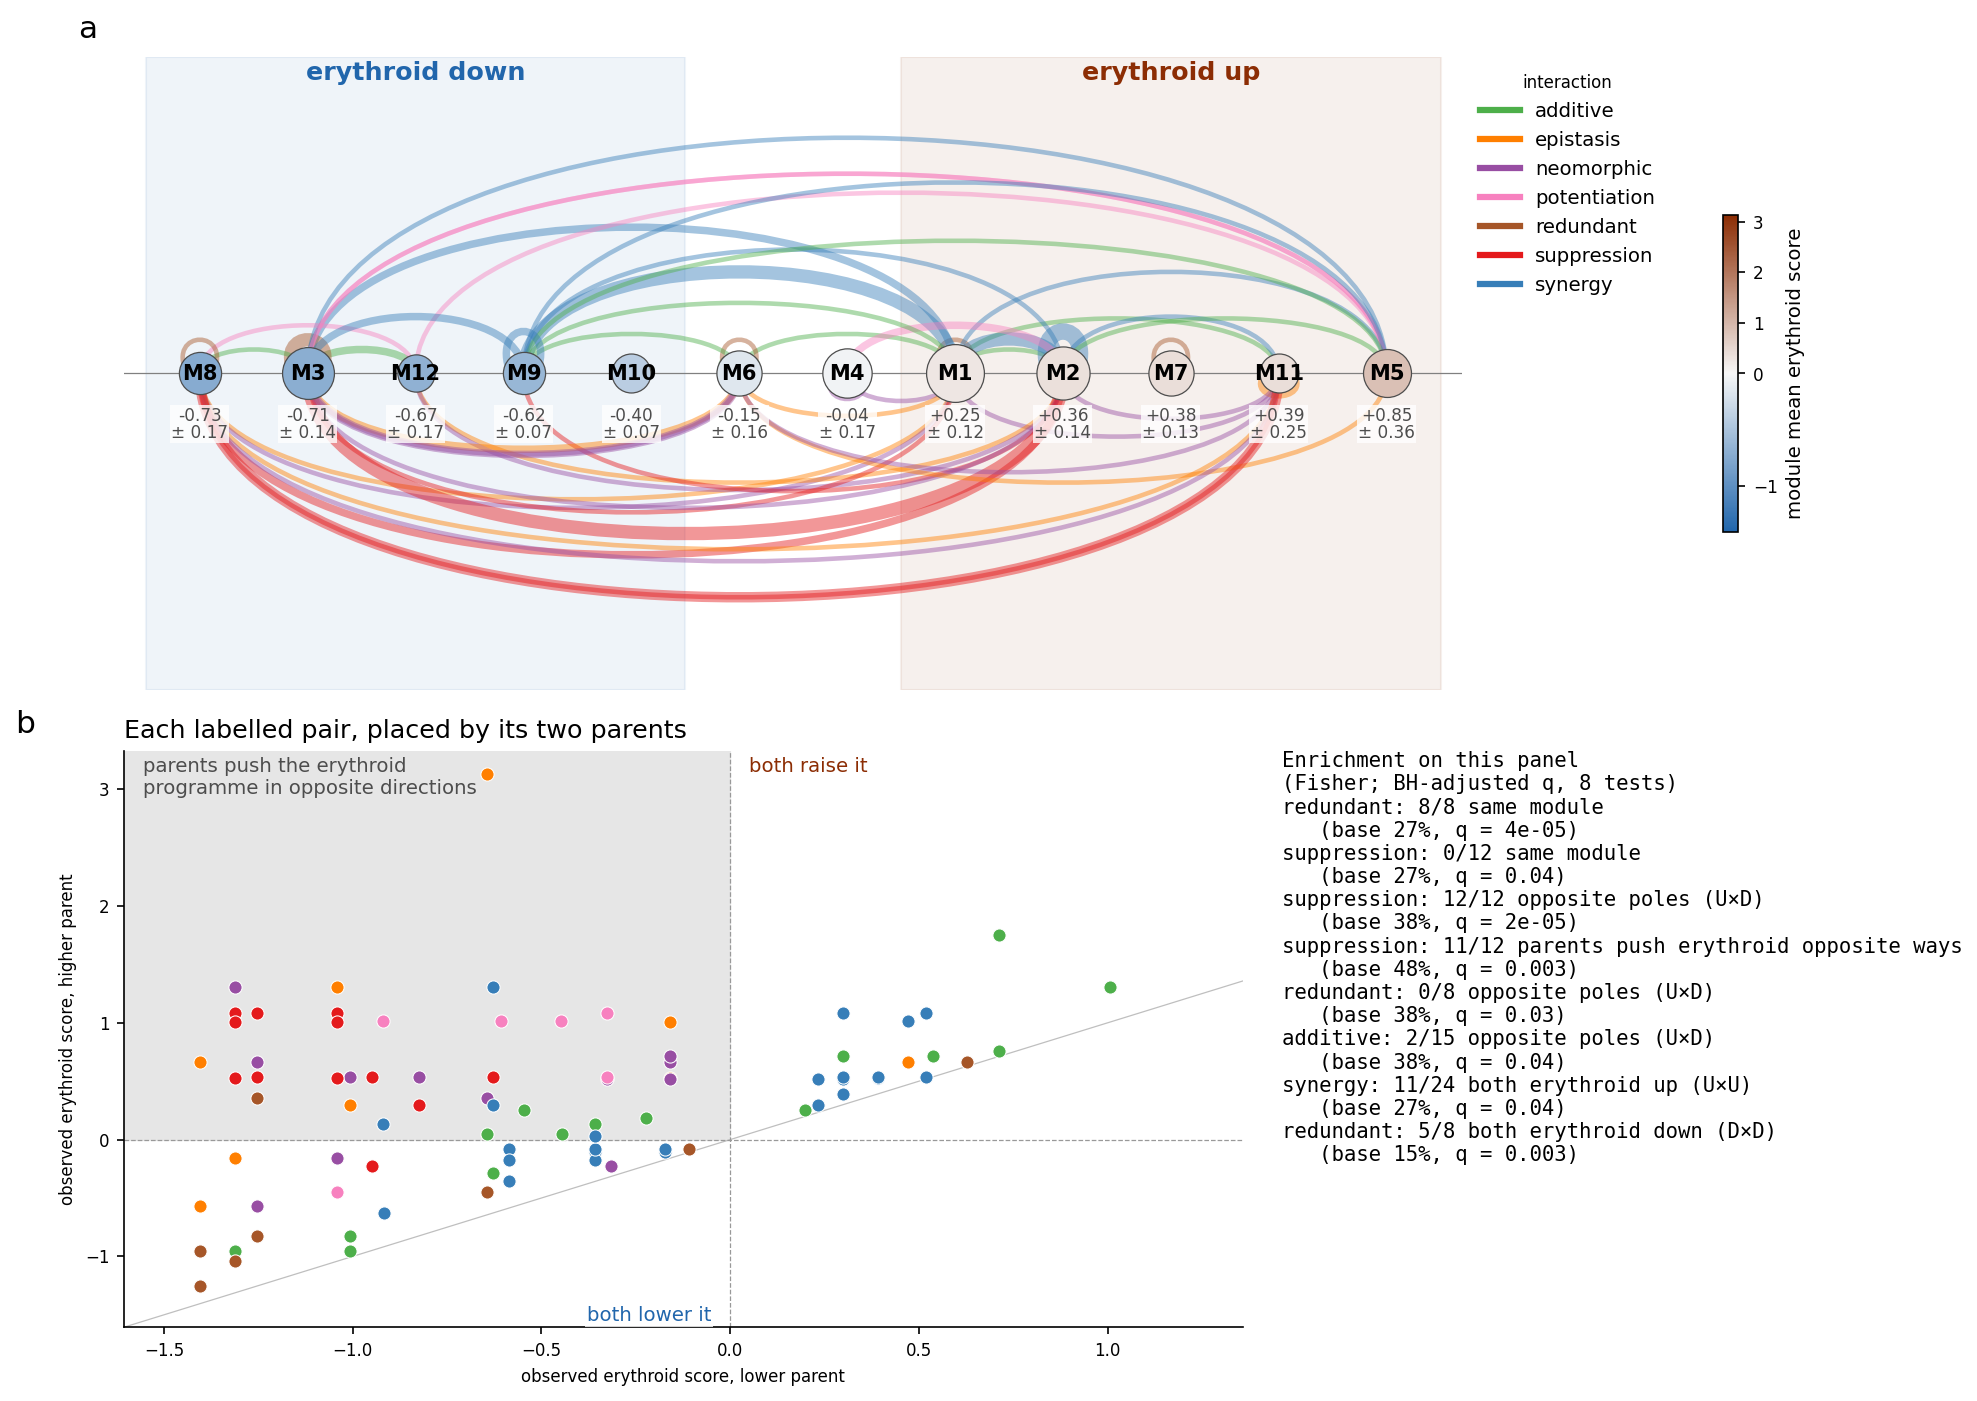

In [9]:
order_m = mods.sort_values('erythroid').index.tolist()     # erythroid down (left) -> up (right)
ery_sem = fate.groupby(module.reindex(genes).values)['erythroid'].sem()     # spread of the module mean
xr = {m_: i for i, m_ in enumerate(order_m)}
COOP = ['approximately additive', 'synergy', 'redundant', 'potentiation']
fig = plt.figure(figsize=(14, 11))
gs_ = fig.add_gridspec(2, 2, height_ratios=[1.1, 1], width_ratios=[1, .42], hspace=.1, wspace=.05)
ax = fig.add_subplot(gs_[0, :])
for pole, col in POLE_C.items():
    idx = [xr[m_] for m_ in order_m if mods.loc[m_, 'pole'] == pole]
    if idx and pole != 'neutral':
        ax.axvspan(min(idx) - .5, max(idx) + .5, color=col, alpha=.07)
        ax.text((min(idx) + max(idx)) / 2, 6.4, pole, color=col, fontsize=12.2, fontweight='bold', ha='center')
off = dict(zip(CLASSES, np.linspace(-.18, .18, len(CLASSES))))
for (ma, mb, cls), n in lab.groupby(['module_a', 'module_b', 'gi']).size().items():
    xa, xb = sorted([xr[ma], xr[mb]])
    sgn = 1 if cls in COOP else -1
    if xa == xb:
        h = sgn * (0.5 + 0.12 * CLASSES.index(cls))
        verts = [(xa - .12, 0), (xa - .32, h), (xa + .32, h), (xa + .12, 0)]
    else:
        h = sgn * (0.55 * (xb - xa) + 0.3) * (1 + off[cls])
        verts = [(xa, 0), (xa, h), (xb, h), (xb, 0)]
    ax.add_patch(mpl.patches.PathPatch(MPath(verts, [MPath.MOVETO, MPath.CURVE4, MPath.CURVE4, MPath.CURVE4]),
                                       fc='none', ec=PALETTE[cls], lw=.8 + 1.4 * n, alpha=.45))
for m_ in order_m:
    r_ = mods.loc[m_]
    ax.scatter(xr[m_], 0, s=230 + 30 * r_['n'], color=ERY_CMAP(enorm(r_['erythroid'])), edgecolor='0.3',
               lw=.6, zorder=5)
    ax.text(xr[m_], 0, m_, ha='center', va='center', fontsize=10.1, fontweight='bold', zorder=6, color='k')
    ax.text(xr[m_], -1.4, f"{r_['erythroid']:+.2f}\n± {ery_sem[m_]:.2f}", ha='center', fontsize=8.1,
            color='0.3', zorder=6, linespacing=.95,
            bbox=dict(fc='white', ec='none', pad=.5, alpha=.8))
ax.axhline(0, color='0.5', lw=.6)
ax.set_xlim(-.7, len(order_m) - .3); ax.set_ylim(-6.9, 6.9); ax.set_xticks([]); ax.set_yticks([])
for s_ in ['left', 'bottom']:
    ax.spines[s_].set_visible(False)
h_cls = [mpl.lines.Line2D([], [], color=PALETTE[c], lw=3, label=short(c)) for c in CLASSES]
ax.legend(handles=h_cls, frameon=False, fontsize=9.5, loc='upper left', bbox_to_anchor=(1.0, 1.0), title='interaction')
_cb = fig.colorbar(mpl.cm.ScalarMappable(norm=enorm, cmap=ERY_CMAP), ax=ax, fraction=.018, pad=.16,
                   location='right', shrink=.5)
_cb.set_label('module mean erythroid score', fontsize=9.5)
_cb.ax.tick_params(labelsize=8.1)
ax.text(-0.02, 1.02, 'a', transform=ax.transAxes, fontsize=15, va='bottom', ha='right')

ax2 = fig.add_subplot(gs_[1, 0])
lo, hi = lab['ery_lo'].min() - .2, lab['ery_hi'].max() + .2
ax2.add_patch(mpl.patches.Rectangle((lo, 0), 0 - lo, hi, color='0.9', zorder=0))
ax2.plot([lo, hi], [lo, hi], color='0.75', lw=.6)
ax2.axvline(0, color='0.6', ls='--', lw=.6); ax2.axhline(0, color='0.6', ls='--', lw=.6)
for c in CLASSES:
    s_ = lab[lab['gi'] == c]
    ax2.scatter(s_['ery_lo'], s_['ery_hi'], s=40, color=PALETTE[c], edgecolor='white', lw=.5, label=short(c), zorder=3)
ax2.text(lo + .05, hi - .05, 'parents push the erythroid\nprogramme in opposite directions', fontsize=9.5, va='top', color='0.3')
ax2.text(.05, hi - .05, 'both raise it', fontsize=9.5, va='top', color=POLE_C['erythroid up'])
xhi = max(lab['ery_lo'].max(), 0) + .35
ax2.text(-.05, lo + .05, 'both lower it', fontsize=9.5, color=POLE_C['erythroid down'], ha='right',
         bbox=dict(fc='white', ec='none', pad=1, alpha=.8))
ax2.set(xlim=(lo, xhi), ylim=(lo, hi), xlabel='observed erythroid score, lower parent',
        ylabel='observed erythroid score, higher parent')
ax2.text(-0.08, 1.02, 'b', transform=ax2.transAxes, fontsize=15, va='bottom', ha='right')
ax2.set_title('Each labelled pair, placed by its two parents', fontsize=12.2, loc='left')

ax3 = fig.add_subplot(gs_[1, 1]); ax3.axis('off')
txt = ['Enrichment on this panel', '(Fisher; BH-adjusted q, 8 tests)']
for _, r_ in claims.iterrows():
    txt.append(f"{r_['class']}: {r_['in']} {r_['where']}\n   (base {r_['base rate']}, q = {r_['q (BH)']:.1g})")
ax3.text(0, 1, '\n'.join(txt), va='top', fontsize=9.9, family='monospace')
plt.show()

### 2. Modules, Norman's functional clusters, fate programmes and latent axes

One row per module, ordered from erythroid up to erythroid down. **(a)** Overlap with Norman's
perturbation-map clusters (Table S6B) and named phenotype groups: dot size = shared genes, dot colour =
the module's fate identity. The strip above gives each Norman cluster's own observed erythroid and
granulocytic scores; the percentage is the share of the cluster that falls in its best module, and *
marks clusters more concentrated than in random modules of the same sizes (5,000 permutations,
BH-adjusted q < 0.05 across the 20 clusters).
**(b)** The module's observed programme scores (canonical markers; the megakaryocytic column is a weak
signal — reliability 0.84 versus ≥ 0.97 for the other two, see section 4). **(c)** The module's mean loading on
each latent axis that at least one perturbation opens; the strip above is each axis's programme
content (decoded erythroid and granulocytic genes).

Clusters more concentrated than random modules (BH q < 0.05): 9 / 20;  mean share in best module 0.79 vs 0.41 by chance


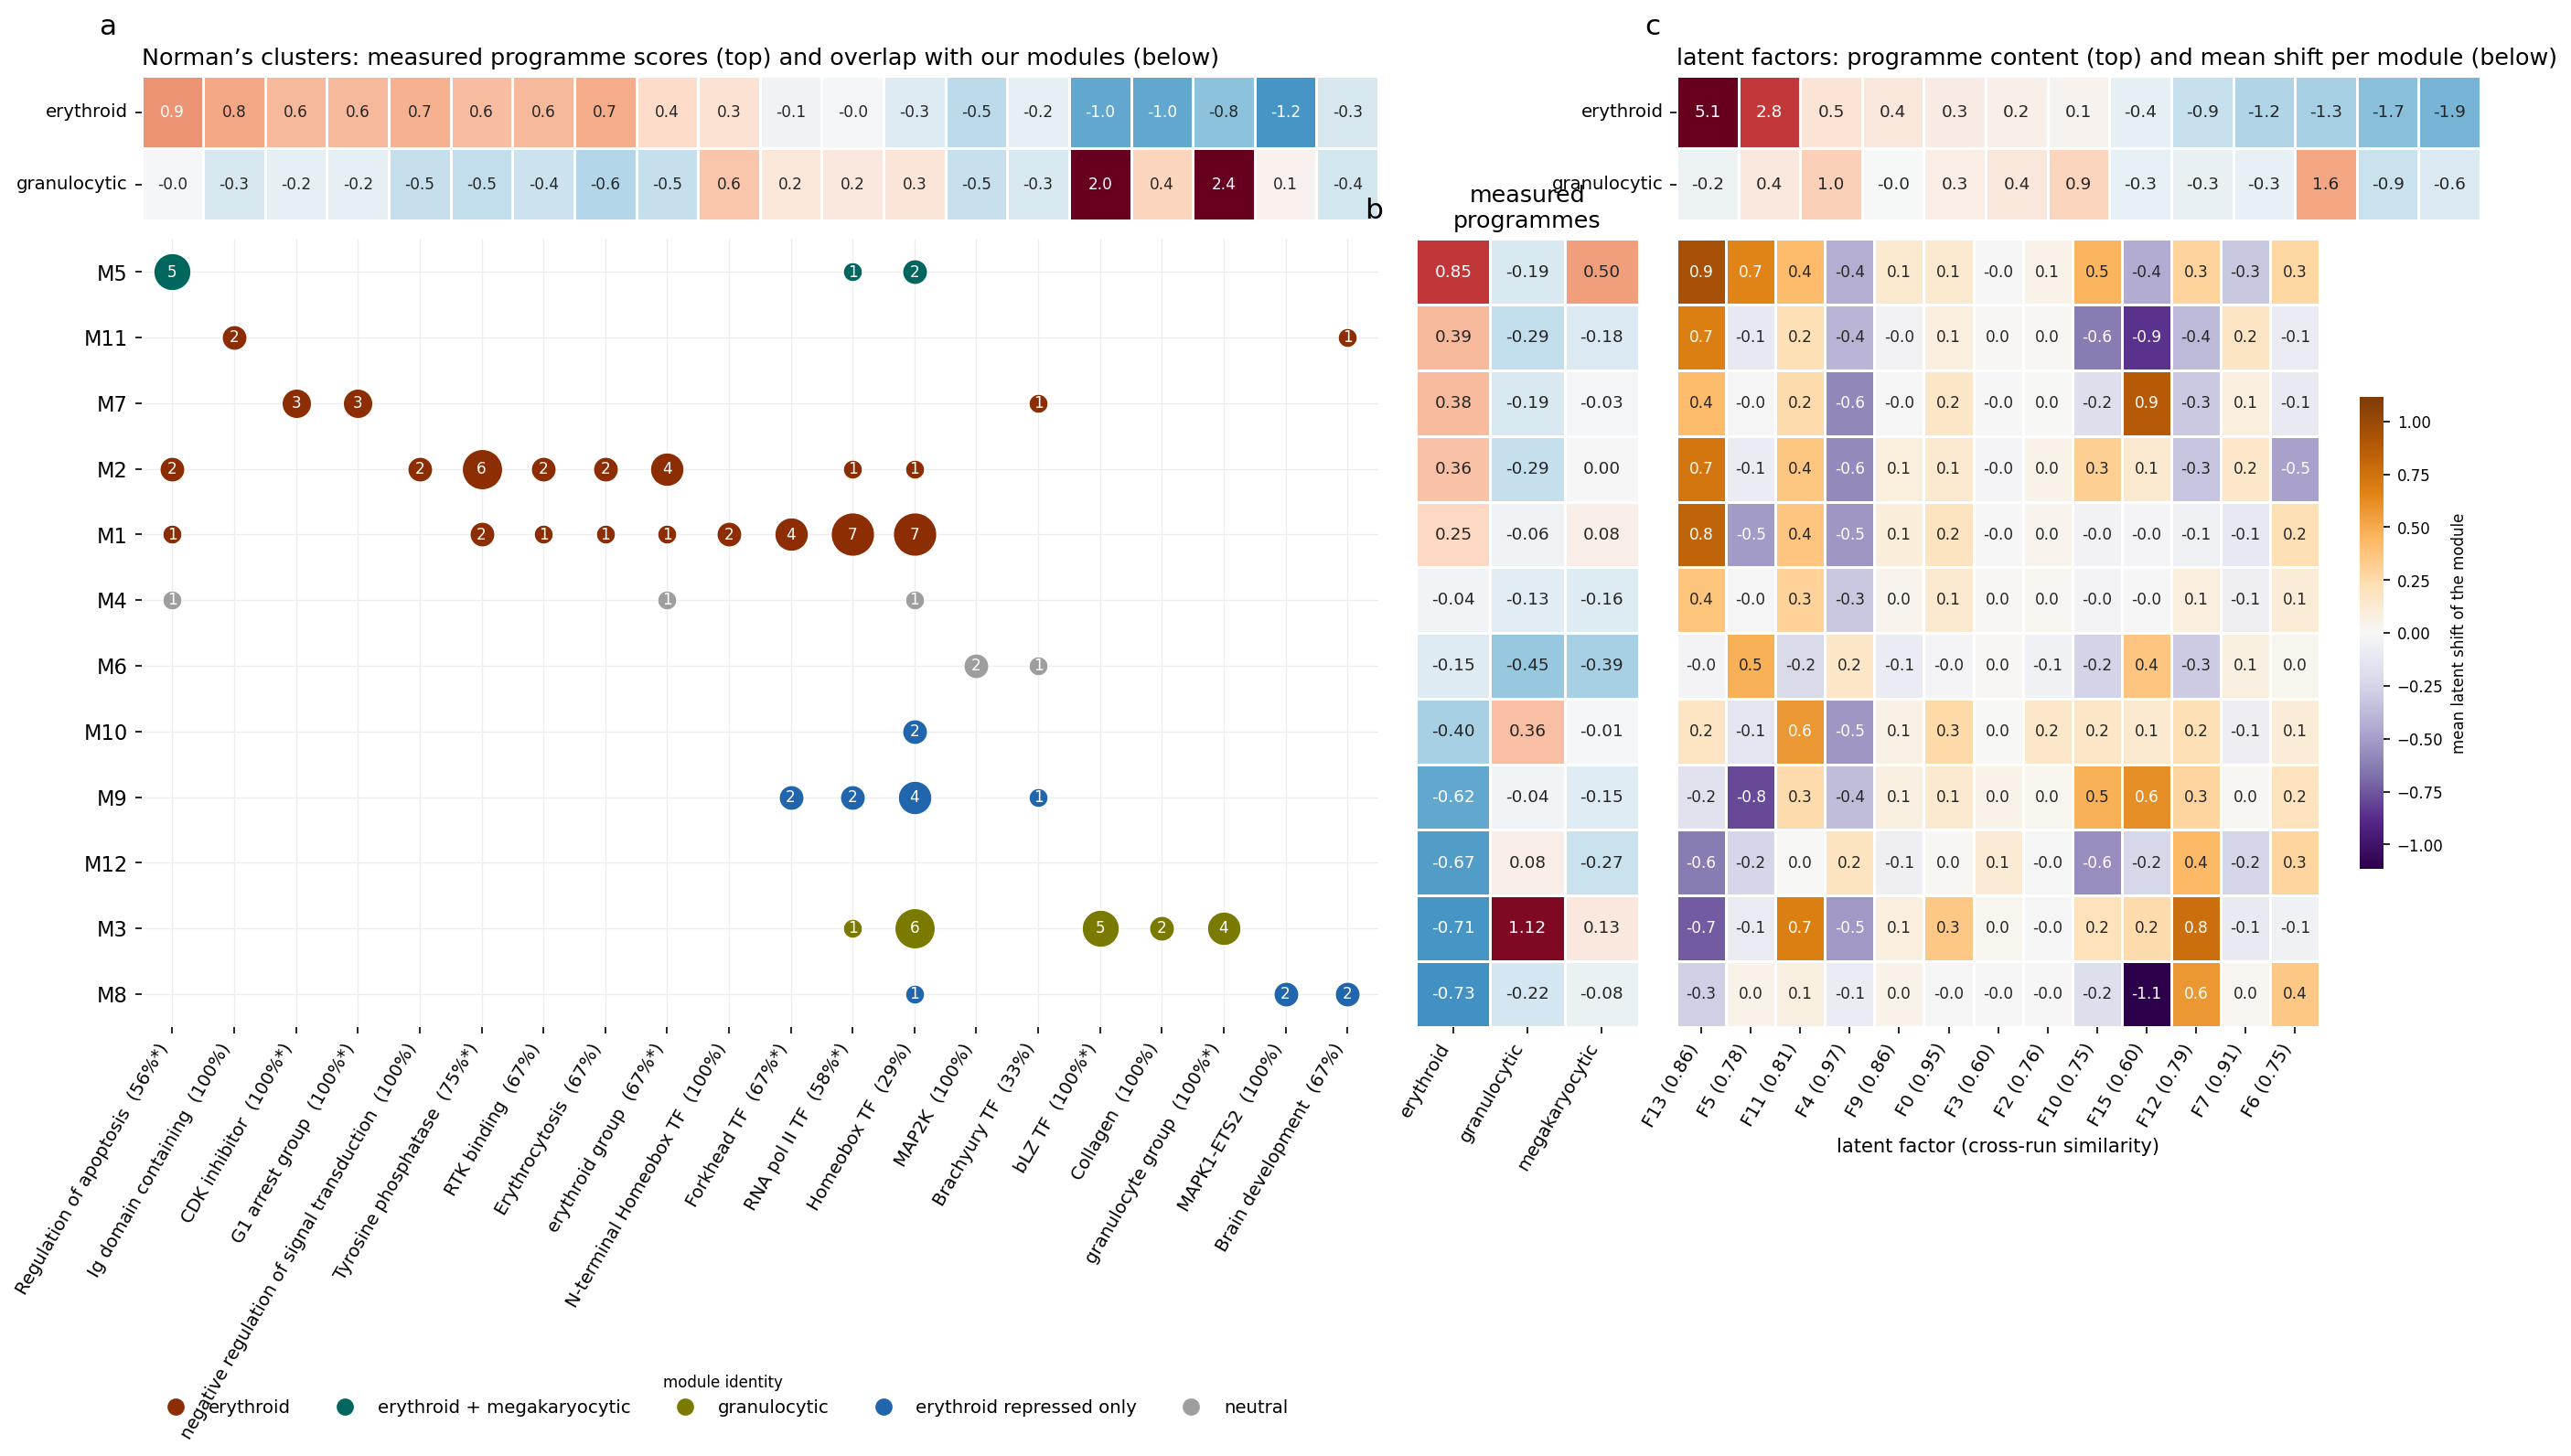

,Norman cluster,n,best module,in best module,expected (random modules),erythroid,granulocytic,q (BH)
0,Regulation of apoptosis,9,M5,0.556,0.287,0.904,-0.024,0.032
1,Ig domain containing,2,M11,1.000,0.547,0.766,-0.329,0.126
2,CDK inhibitor,3,M7,1.000,0.420,0.649,-0.176,0.019
3,G1 arrest group,3,M7,1.000,0.420,0.649,-0.176,0.019
4,negative regulation of signal transduction,2,M2,1.000,0.547,0.713,-0.470,0.126
5,Tyrosine phosphatase,8,M2,0.750,0.300,0.618,-0.495,0.004
6,RTK binding,3,M2,0.667,0.427,0.648,-0.433,0.285
7,Erythrocytosis,3,M2,0.667,0.425,0.744,-0.582,0.285
8,erythroid group,6,M2,0.667,0.331,0.390,-0.478,0.032
9,N-terminal Homeobox TF,2,M1,1.000,0.548,0.311,0.562,0.126


In [10]:
from statsmodels.stats.multitest import multipletests
# Norman's perturbation-map clusters (Table S6B) plus his named phenotype groups
_s6b = pd.read_excel(Path(paths.DATA_DIR) / 'norman' / 'aax4438_tables6.xlsx', sheet_name='Table S6B Perturb map annot', header=None).values.tolist()
norman_fx = {}
for i, rr in enumerate(_s6b[:-1]):
    if str(rr[0]).strip().isdigit():
        mem = [g.strip() for g in str(_s6b[i + 1][0]).split(',') if g.strip() in g2i]
        if len(mem) >= 2:
            norman_fx[str(rr[1]).strip()] = mem
for k, v in NORMAN.items():
    norman_fx[f'{k} group'] = v

# correspondence: share of each cluster in its best module, against random modules of the same sizes
order_m = mods.sort_values('erythroid', ascending=False).index.tolist()
mcode = module.reindex(genes).map({m_: i for i, m_ in enumerate(MODULES)}).values
rng_ = np.random.default_rng(0)
perm_codes = np.stack([rng_.permutation(mcode) for _ in range(5000)])
rows = []
for name, mem in norman_fx.items():
    idx = [g2i[g] for g in mem]
    counts = module[mem].value_counts()
    frac = counts.iloc[0] / len(mem)
    null = (perm_codes[:, idx][..., None] == np.arange(len(MODULES))).sum(1).max(1) / len(mem)
    rows.append({'Norman cluster': name, 'n': len(mem), 'best module': counts.index[0], 'in best module': frac,
                 'expected (random modules)': null.mean(), 'p': (np.sum(null >= frac) + 1) / (len(null) + 1),
                 'erythroid': fate.loc[mem, 'erythroid'].mean(), 'granulocytic': fate.loc[mem, 'granulocytic'].mean()})
fx = pd.DataFrame(rows)
fx['q (BH)'] = multipletests(fx['p'], method='fdr_bh')[1]
fx = fx.drop(columns='p')
fx['_order'] = fx['best module'].map({m_: i for i, m_ in enumerate(order_m)})
fx = fx.sort_values(['_order', 'in best module'], ascending=[True, False]).drop(columns='_order').reset_index(drop=True)
print(f"Clusters more concentrated than random modules (BH q < 0.05): {(fx['q (BH)'] < .05).sum()} / {len(fx)};  "
      f"mean share in best module {fx['in best module'].mean():.2f} vs {fx['expected (random modules)'].mean():.2f} by chance")

ID_COL = {'erythroid': '#8c2d04', 'erythroid + megakaryocytic': '#01665e', 'granulocytic': '#7a7a00',
          'erythroid repressed only': '#2166ac', 'neutral': '#9e9e9e'}
ax_order = fac[used].sort_values('erythroid', ascending=False).index.tolist()
mod_load = load.groupby(module.reindex(genes).values).mean().reindex(order_m)[ax_order]
nC, nA, nM = len(fx), len(ax_order), len(order_m)

fig = plt.figure(figsize=(22, 9))
gs2 = fig.add_gridspec(2, 3, width_ratios=[nC, 3.6, nA], height_ratios=[2.2, nM], wspace=.05, hspace=.04)
# (a) strip: each Norman cluster's own programme scores
axs_ = fig.add_subplot(gs2[0, 0])
sns.heatmap(fx[['erythroid', 'granulocytic']].T.values, cmap='RdBu_r', center=0, vmin=-2, vmax=2, cbar=False,
            annot=True, fmt='.1f', annot_kws={'fontsize': 8.1}, linewidths=.5, linecolor='white', ax=axs_,
            xticklabels=False, yticklabels=['erythroid', 'granulocytic'])
axs_.tick_params(axis='y', labelsize=9.5, rotation=0)
axs_.text(-0.02, 1.25, 'a', transform=axs_.transAxes, fontsize=15, va='bottom', ha='right')
axs_.set_title('Norman’s clusters: measured programme scores (top) and overlap with our modules (below)',
               fontsize=12.2, loc='left')
# (a) dot matrix
axd = fig.add_subplot(gs2[1, 0])
for j, r_ in fx.iterrows():
    mem = set(norman_fx[r_['Norman cluster']])
    for i, m_ in enumerate(order_m):
        k = len(mem & set(module.index[module == m_]))
        if k:
            axd.scatter(j + .5, i + .5, s=30 + 70 * k, color=ID_COL[mods.loc[m_, 'identity']], edgecolor='white',
                        lw=.6, zorder=3)
            axd.text(j + .5, i + .5, k, ha='center', va='center', fontsize=8.1, color='white', zorder=4)
axd.set_xlim(0, nC); axd.set_ylim(nM, 0)
axd.set_xticks(np.arange(nC) + .5)
axd.set_xticklabels([f"{c}  ({v:.0%}{'*' if q_ < .05 else ''})" for c, v, q_ in
                     zip(fx['Norman cluster'], fx['in best module'], fx['q (BH)'])], rotation=60, ha='right', fontsize=9.5)
axd.set_yticks(np.arange(nM) + .5); axd.set_yticklabels(order_m, fontsize=10.8)
axd.grid(color='0.93', lw=.6); axd.set_axisbelow(True)
for s_ in axd.spines.values():
    s_.set_visible(False)
axd.legend(handles=[mpl.lines.Line2D([], [], marker='o', ls='', color=c, ms=8, label=k) for k, c in ID_COL.items()],
           title='module identity', frameon=False, fontsize=9.5, loc='upper left', bbox_to_anchor=(0, -.42), ncol=5)
# (b) module programme scores
axp = fig.add_subplot(gs2[1, 1])
sns.heatmap(mods.loc[order_m, ['erythroid', 'granulocytic', 'megakaryocytic']], cmap='RdBu_r', center=0,
            vmin=-1.2, vmax=1.2, annot=True, fmt='.2f', annot_kws={'fontsize': 8.8}, cbar=False, linewidths=.5,
            linecolor='white', ax=axp, yticklabels=False)
axp.set_xticklabels(['erythroid', 'granulocytic', 'megakaryocytic'], rotation=60, ha='right', fontsize=9.5)
axp.text(-0.15, 1.02, 'b', transform=axp.transAxes, fontsize=15, va='bottom', ha='right')
axp.set_title('measured\nprogrammes', fontsize=12.2)
# (c) strip: axis programme content, then module loadings
axt = fig.add_subplot(gs2[0, 2])
sns.heatmap(fac.loc[ax_order, P2].T.values, cmap='RdBu_r', center=0, vmin=-4, vmax=4, cbar=False, annot=True,
            fmt='.1f', annot_kws={'fontsize': 8.8}, linewidths=.5, linecolor='white', ax=axt, xticklabels=False,
            yticklabels=P2)
axt.tick_params(axis='y', labelsize=9.5, rotation=0)
axt.text(-0.02, 1.25, 'c', transform=axt.transAxes, fontsize=15, va='bottom', ha='right')
axt.set_title('latent factors: programme content (top) and mean shift per module (below)', fontsize=12.2, loc='left')
axl = fig.add_subplot(gs2[1, 2])
lim = np.abs(mod_load.values).max()
sns.heatmap(mod_load, cmap='PuOr_r', center=0, vmin=-lim, vmax=lim, annot=True, fmt='.1f', annot_kws={'fontsize': 8.1},
            linewidths=.5, linecolor='white', ax=axl, yticklabels=False,
            cbar_kws={'label': 'mean latent shift of the module', 'shrink': .6})
axl.set_xticklabels([f"{f} ({fac.loc[f, 'cross-run similarity']:.2f})" for f in ax_order], rotation=60, ha='right', fontsize=9.5)
axl.set_xlabel('latent factor (cross-run similarity)', fontsize=10.1)
plt.show()
fx.round(3)

### 3. Who drives the three most interpretable axes

Loadings on F13 (dominant erythroid axis), F5 (erythroid with megakaryocytic-leaning genes) and F12
(granulocytic up, erythroid down). **Each bar is one perturbed gene** (CRISPRa target), coloured by
Norman group; the most extreme genes on each side are named.

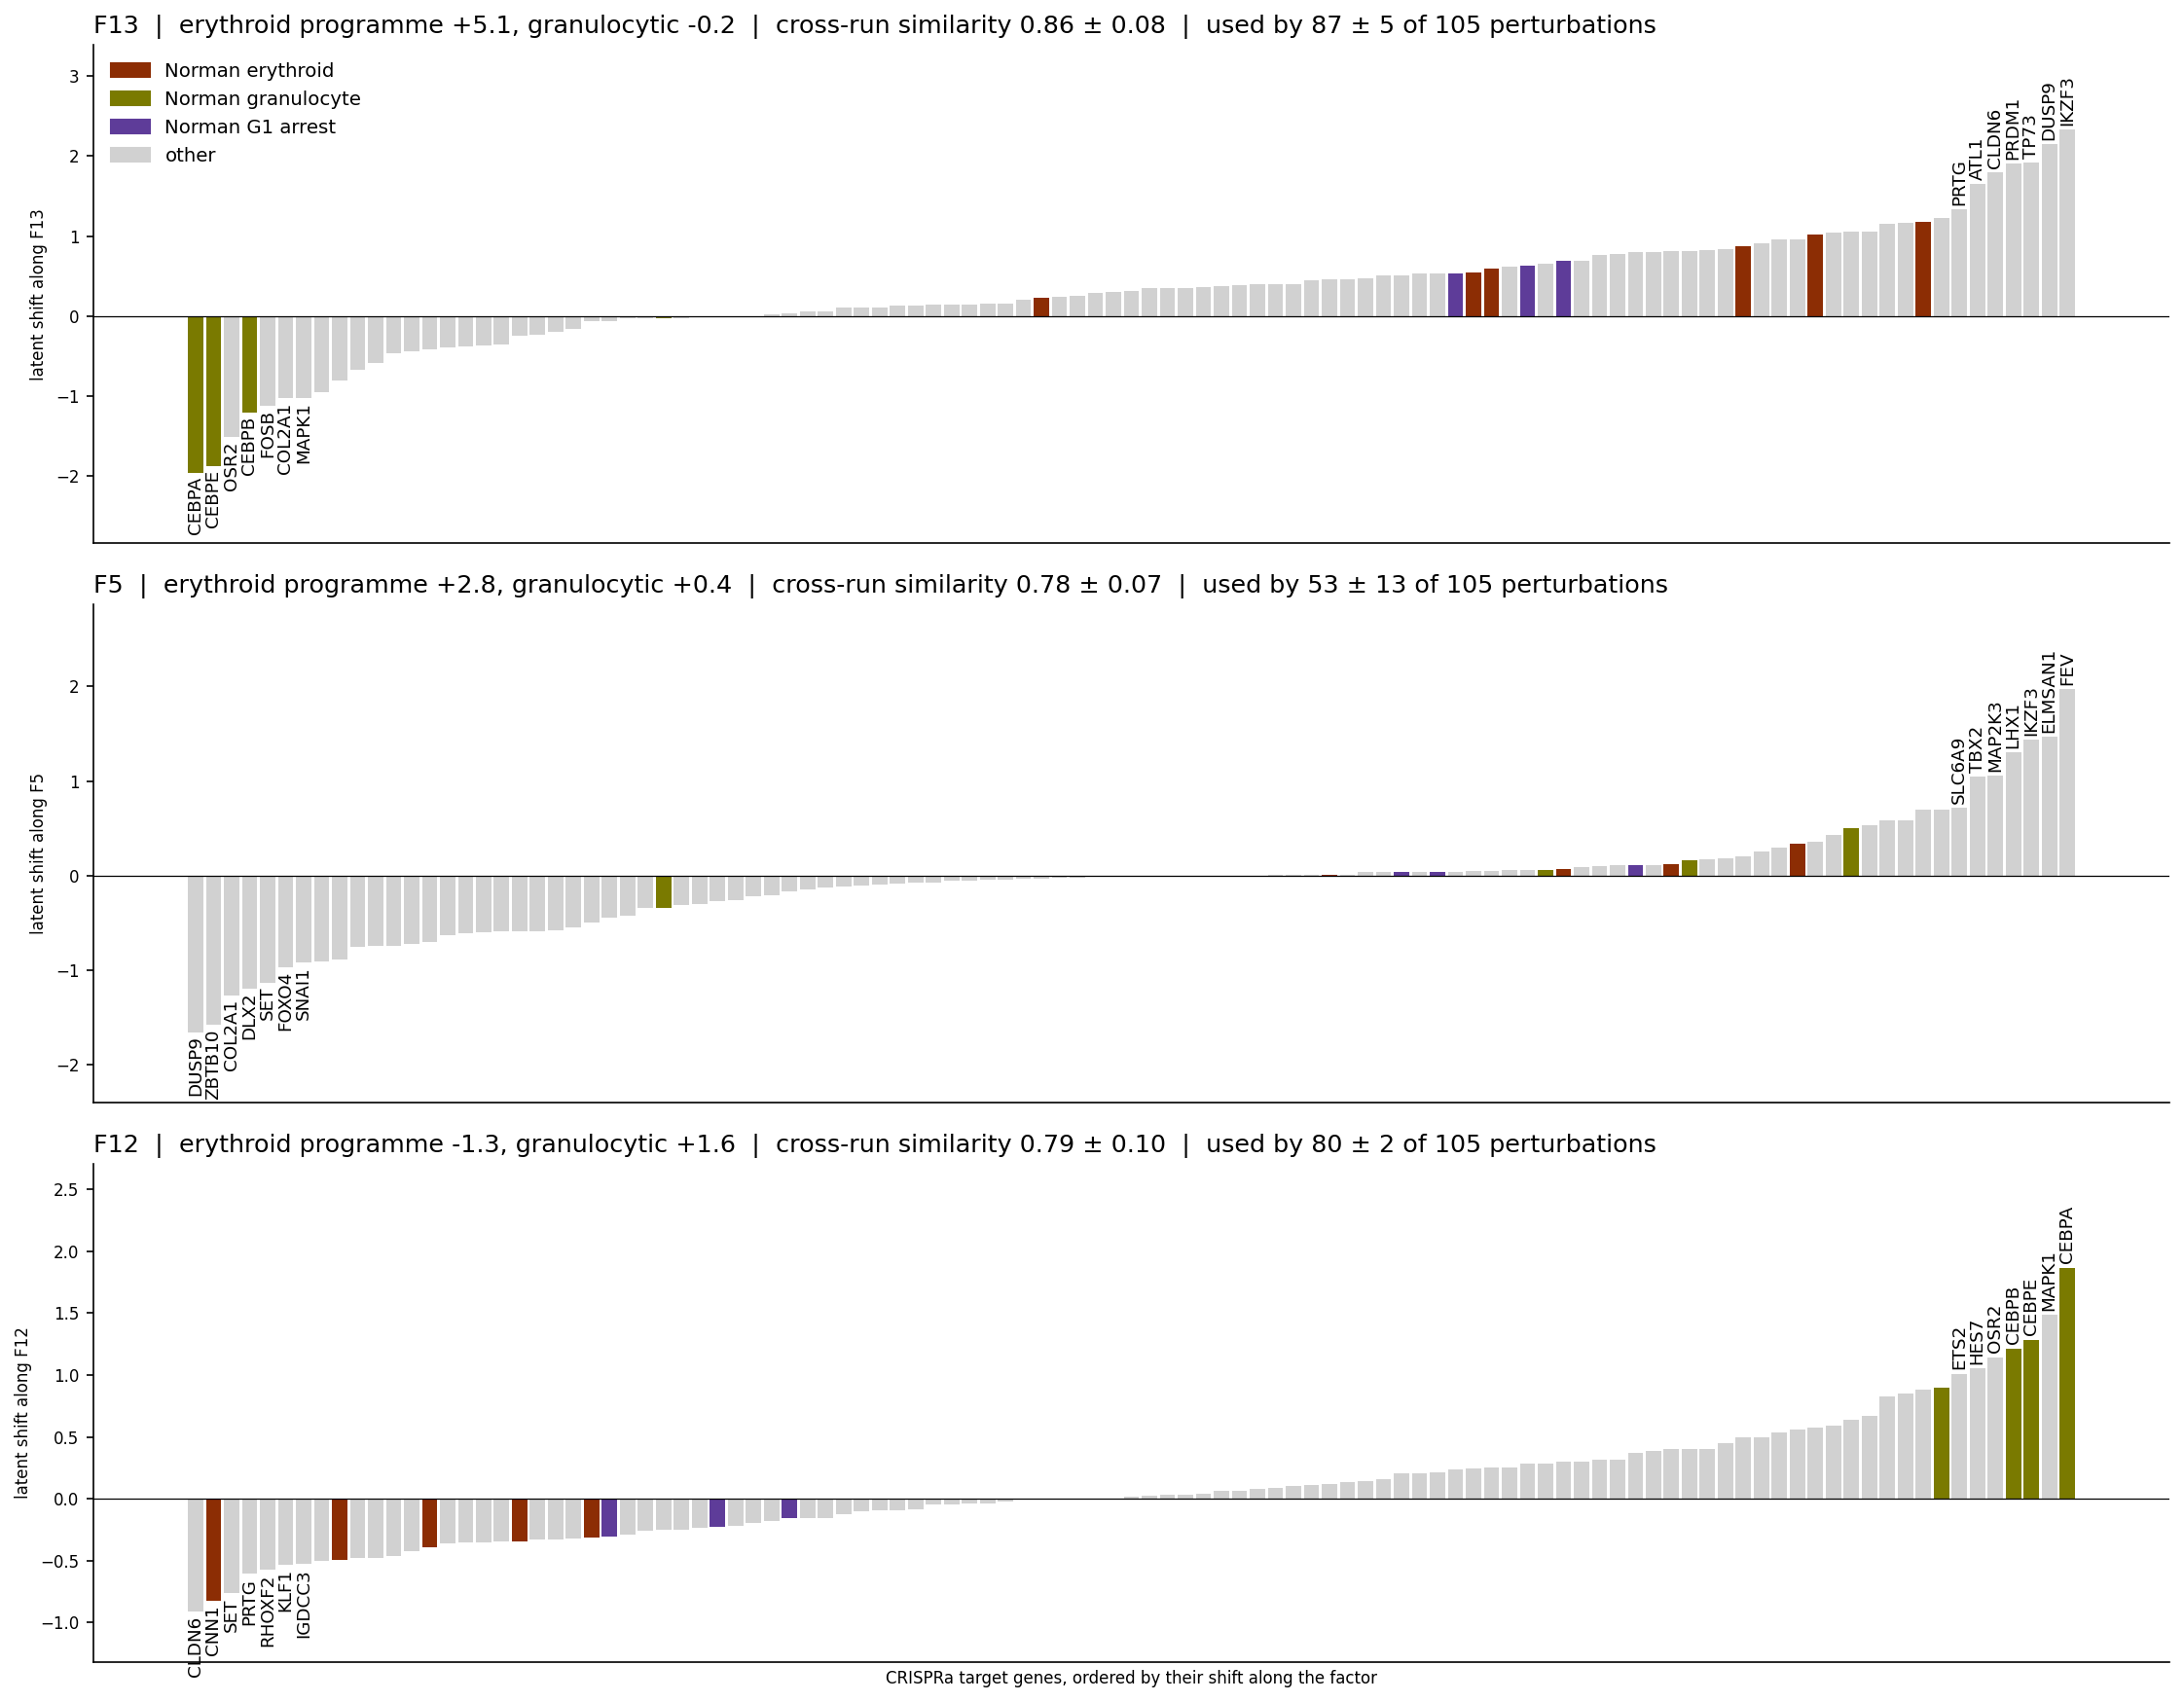

In [11]:
SHOW = [f for f in ['F13', 'F5', 'F12'] if f in fac.index and used[f]]
group_of = {g: k for k, v in NORMAN.items() for g in v}
fig, axs = plt.subplots(len(SHOW), 1, figsize=(15, 3.9 * len(SHOW)))
for ax, f in zip(np.atleast_1d(axs), SHOW):
    lo_ = load[f].sort_values()
    ax.bar(range(len(lo_)), lo_.values, color=[GROUP_C.get(group_of.get(g, ''), '0.82') for g in lo_.index], width=.85)
    span = np.abs(lo_.values).max()
    for i in list(range(7)) + list(range(len(lo_) - 7, len(lo_))):
        ax.text(i, lo_.values[i] + np.sign(lo_.values[i]) * .02 * span, lo_.index[i], rotation=90, fontsize=8.8,
                ha='center', va='bottom' if lo_.values[i] > 0 else 'top')
    ax.axhline(0, color='k', lw=.6); ax.set_xticks([])
    ax.set_ylim(lo_.min() * 1.45, lo_.max() * 1.45)
    ax.set_ylabel(f'latent shift along {f}')
    ax.set_title(f"{f}  |  erythroid programme {fac.loc[f, 'erythroid']:+.1f}, granulocytic "
                 f"{fac.loc[f, 'granulocytic']:+.1f}  |  cross-run similarity "
                 f"{fac.loc[f, 'cross-run similarity']:.2f} ± {fac.loc[f, 'similarity sd']:.2f}  |  used by "
                 f"{fac.loc[f, 'perts using']:.0f} ± {fac.loc[f, 'perts using sd']:.0f} of {P} perturbations",
                 fontsize=12.2, loc='left')
np.atleast_1d(axs)[0].legend(handles=[mpl.patches.Patch(color=c, label=f'Norman {k}') for k, c in GROUP_C.items()] +
                             [mpl.patches.Patch(color='0.82', label='other')], frameon=False, fontsize=9.5, loc='upper left')
np.atleast_1d(axs)[-1].set_xlabel('CRISPRa target genes, ordered by their shift along the factor')
plt.tight_layout(); plt.show()

### 4. The neomorphic rule

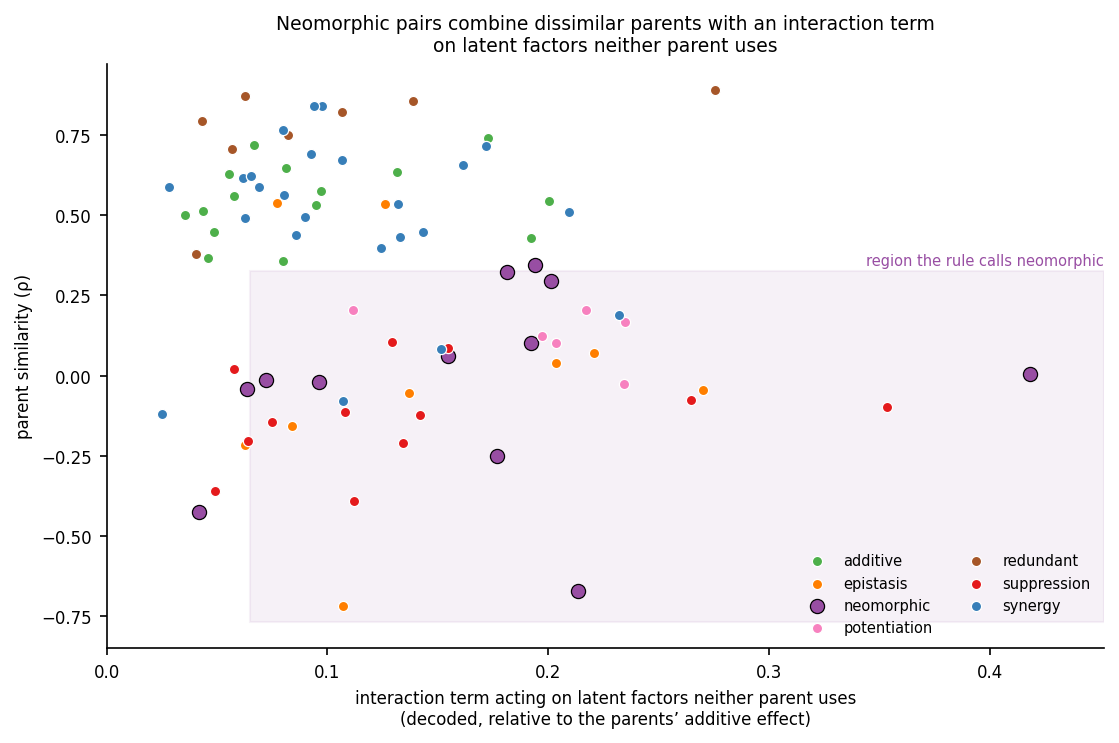

In [12]:
fig, ax = plt.subplots(figsize=(7.5, 5))
for c in CLASSES:
    s_ = lab[lab['gi'] == c]
    ax.scatter(s_['syn_offgate_dec'], s_['rho'], s=46 if c == 'neomorphic' else 24, color=PALETTE[c],
               edgecolor='k' if c == 'neomorphic' else 'white', lw=.6, label=short(c), zorder=3)
(_, _, x0), (_, _, y1) = dict(RULES)['neomorphic']
xmax = lab['syn_offgate_dec'].max() * 1.08
ax.add_patch(mpl.patches.Rectangle((x0, lab['rho'].min() - .05), xmax - x0, y1 - lab['rho'].min() + .05,
                                   color=PALETTE['neomorphic'], alpha=.08, zorder=0))
ax.text(xmax, y1 + .01, 'region the rule calls neomorphic', ha='right', va='bottom', fontsize=7,
        color=PALETTE['neomorphic'])
ax.set(xlabel='interaction term acting on latent factors neither parent uses\n(decoded, relative to the parents\u2019 additive effect)',
       ylabel='parent similarity (ρ)', xlim=(0, xmax))
ax.legend(frameon=False, fontsize=7, ncol=2, loc='lower right')
ax.set_title('Neomorphic pairs combine dissimilar parents with an interaction term\non latent factors neither parent uses', fontsize=9)
plt.tight_layout(); plt.show()

### 5. What each interaction looks like in the model

Drawn from real data — the **mean descriptors of each class's labelled pairs** — placed on a schematic
geometry: the angle between parents A and B is arccos(mean ρ); B is shortened by the mean dominance
(`dom_gap`); the solid arrow is the sum scaled by the mean `joint_over_add`; the dotted arrow's length is
proportional to the mean `syn_offgate_dec`. Only the dotted arrow's direction is arbitrary.

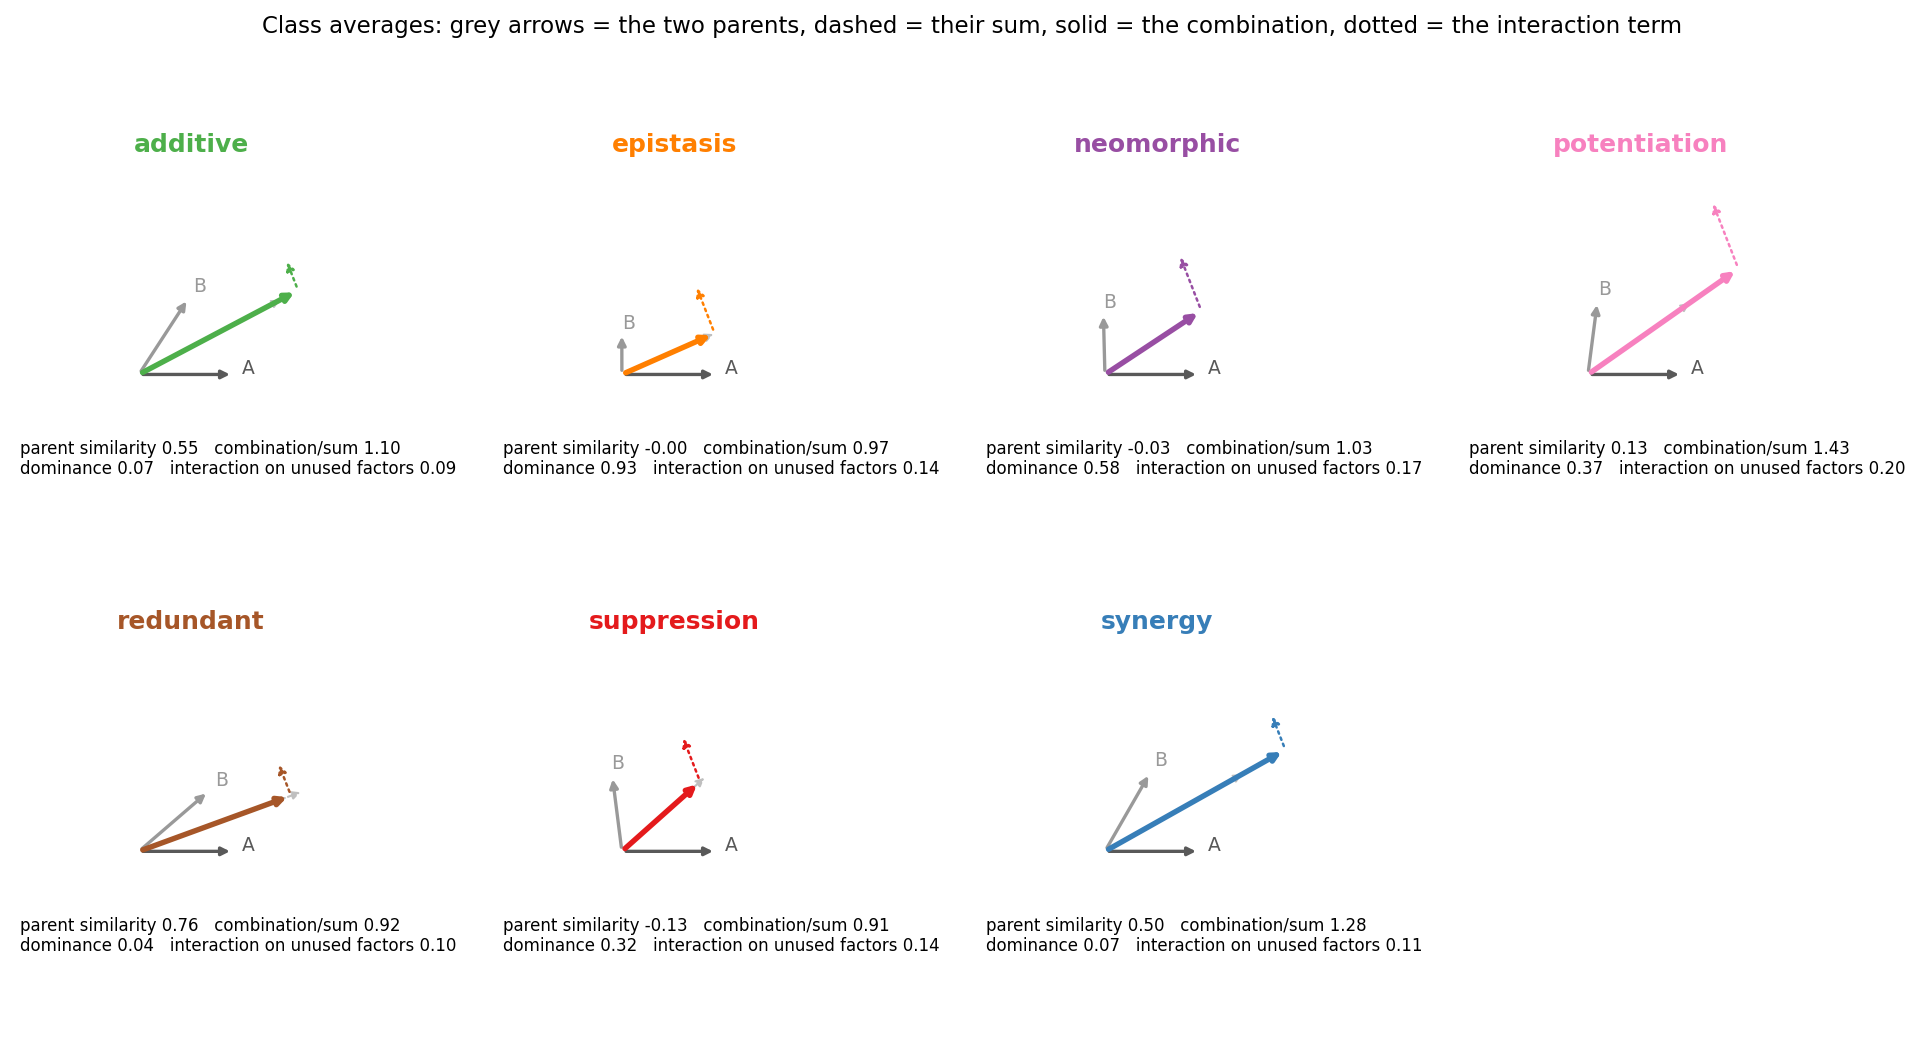

In [13]:
cm_ = lab.groupby('gi')[DESC7].mean().reindex(CLASSES)
fig, axs = plt.subplots(2, 4, figsize=(13, 7))       # two rows so the vectors are large enough to read
axs = axs.ravel()
axs[-1].axis('off')                                   # seven classes in an eight-panel grid
for ax, c in zip(axs, CLASSES):
    r_ = cm_.loc[c]
    th = np.arccos(np.clip(r_['rho'], -1, 1))               # angle between parents from rho
    a = np.array([1.0, 0.0])
    b = (1 - 0.6 * r_['dom_gap']) * np.array([np.cos(th), np.sin(th)])   # shorter partner = dominance
    comb = (a + b) * r_['joint_over_add']                   # size relative to the sum
    syn_v = np.array([-0.35, 0.9]) * r_['syn_offgate_dec'] * 4
    for v, col, lab_ in [(a, '0.35', 'A'), (b, '0.6', 'B')]:
        ax.annotate('', xy=v, xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color=col, lw=1.6))
        ax.text(*(v * 1.08), lab_, fontsize=9, color=col)
    ax.annotate('', xy=a + b, xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color='0.75', lw=1, ls='--'))
    ax.annotate('', xy=comb, xytext=(0, 0), arrowprops=dict(arrowstyle='-|>', color=PALETTE[c], lw=2.6))
    ax.annotate('', xy=comb + syn_v, xytext=comb, arrowprops=dict(arrowstyle='-|>', color=PALETTE[c], lw=1.2, ls=':'))
    ax.set_xlim(-1.3, 2.4); ax.set_ylim(-1.1, 2.2); ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(short(c), color=PALETTE[c], fontsize=12, fontweight='bold')
    ax.text(-1.25, -1.05, f"parent similarity {r_['rho']:.2f}   combination/sum {r_['joint_over_add']:.2f}\n"
                          f"dominance {r_['dom_gap']:.2f}   interaction on unused factors "
                          f"{r_['syn_offgate_dec']:.2f}", fontsize=8)
fig.suptitle('Class averages: grey arrows = the two parents, dashed = their sum, '
             'solid = the combination, dotted = the interaction term', fontsize=11, y=1.0)
plt.tight_layout(); plt.show()

### 6. Worked examples: parents, predicted and observed combination

Programme scores (erythroid, granulocytic) of each parent, the model's predicted combination and the
measured combination. A score is the mean change of the programme's genes relative to control, in units
of that profile's own gene-wise spread: **positive = the programme is switched on, negative = it is
pushed below control** (e.g. the C/EBPs lower the erythroid genes). All five pairs were in the model's
training set, so this shows fit rather than prediction.

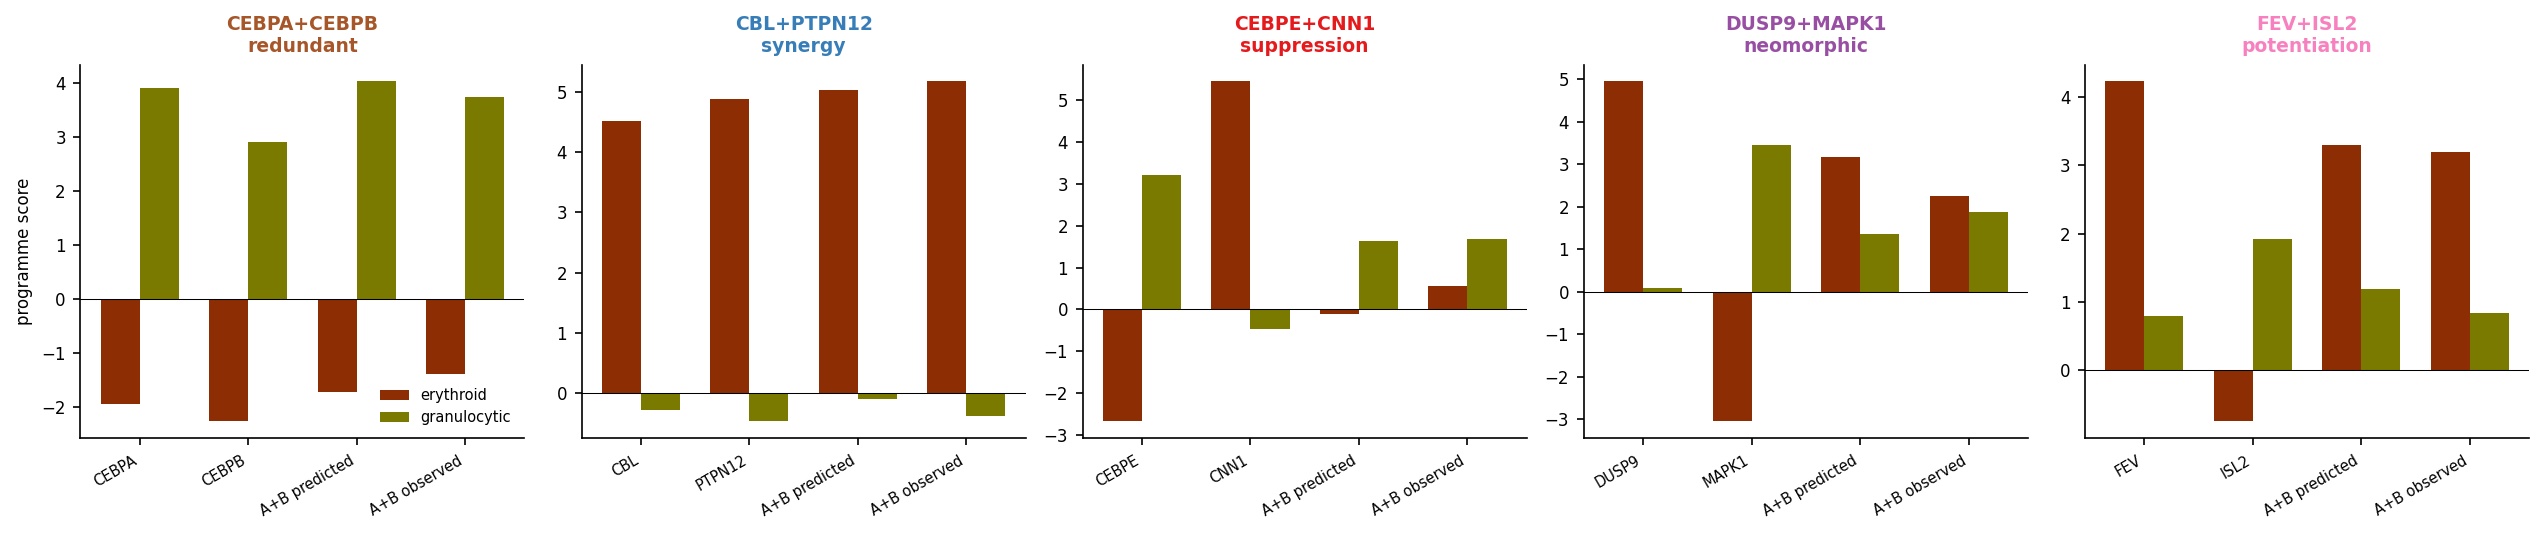

In [14]:
canon_lbl = np.array(['+'.join(sorted(l.split('+'))) if '+' in l else l for l in labels])
ntc_f = _pb(labels == NTC)
obs_vec = lambda lbl: _pb(canon_lbl == lbl) - ntc_f
EX_CLASS = dict(zip(lab['combination'], lab['gi']))
fig, axs = plt.subplots(1, len(EXAMPLES), figsize=(17, 3.6))
for ax, e in zip(axs, EXAMPLES):
    A_, B_ = e
    pred = np.mean(ex_pred[e], 0)
    obs = np.stack([obs_vec(A_), obs_vec(B_), obs_vec('+'.join(sorted(e)))])
    sc_p = prog_score(pred).values; sc_o = prog_score(obs).values
    rows = [(A_, sc_p[0]), (B_, sc_p[1]), ('A+B predicted', sc_p[2]), ('A+B observed', sc_o[2])]
    x = np.arange(len(rows)); w = .36
    for j, pname in enumerate(P2):
        ax.bar(x + (j - .5) * w, [r[1][j] for r in rows], width=w, color=PROG_C[pname], label=pname)
    ax.axhline(0, color='k', lw=.5)
    ax.set_xticks(x); ax.set_xticklabels([r[0] for r in rows], rotation=30, ha='right', fontsize=7)
    cls = EX_CLASS['+'.join(sorted(e))]
    ax.set_title(f"{A_}+{B_}\n{short(cls)}", color=PALETTE[cls], fontsize=9, fontweight='bold')
axs[0].set_ylabel('programme score'); axs[0].legend(frameon=False, fontsize=7)
plt.tight_layout(); plt.show()

### 7. Descriptor fingerprint

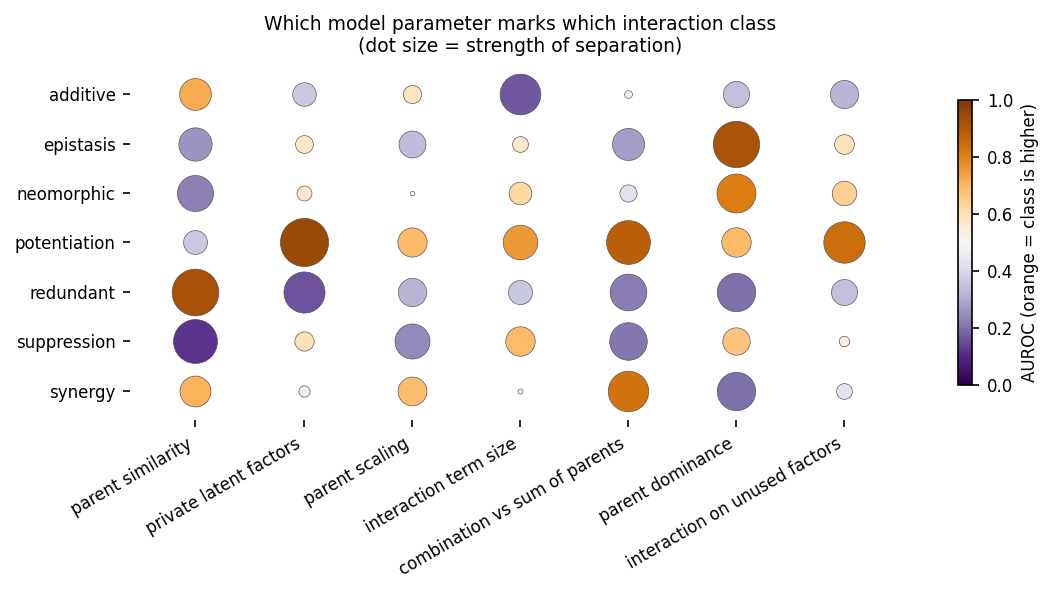

In [15]:
fig, ax = plt.subplots(figsize=(7.5, 4))
for i, c in enumerate(CLASSES):
    for j, f in enumerate(DESC7):
        v = auc.loc[c, f]
        ax.scatter(j, i, s=1400 * abs(v - .5) ** 1.2 + 4, color=plt.cm.PuOr_r(v), edgecolor='0.3', lw=.3)
ax.set_xticks(range(len(DESC7))); ax.set_xticklabels([NAMES[f] for f in DESC7], rotation=30, ha='right')
ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels([short(c) for c in CLASSES])
ax.invert_yaxis(); ax.set_xlim(-.6, len(DESC7) - .4); ax.set_ylim(len(CLASSES) - .4, -.6)
sm = mpl.cm.ScalarMappable(cmap='PuOr_r', norm=mpl.colors.Normalize(0, 1)); sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=.8, label='AUROC (orange = class is higher)')
ax.set_title('Which model parameter marks which interaction class\n(dot size = strength of separation)')
for s_ in ax.spines.values():
    s_.set_visible(False)
plt.tight_layout(); plt.show()

## 6. Numbers quoted in the manuscript

Every quantity the text reports that is not already printed above: the spread of each module's position,
bootstrap uncertainty and BH-adjusted q for the fate-score correlations, run-to-run spread of the factor
programme content and of the strongest perturbation couplings, the descriptor spread behind the
opposite-pole comparison, and how the pole-level claims respond to moving the two borderline modules.
(The neomorphism支 checks H1/H2 are computed in `module_interaction.ipynb`, sections 11i-11k.)

In [16]:
from scipy.stats import pearsonr, fisher_exact
from statsmodels.stats.multitest import multipletests
rng_a = np.random.default_rng(0)

print('module position on the erythroid axis (observed marker score)')
_g = fate.groupby(module.reindex(genes).values)['erythroid']
_pos = pd.DataFrame({'mean': _g.mean(), 'SEM': _g.sem(), 'SD': _g.std(), 'n': _g.size()}).reindex(MODULES)
print(_pos.round(2).to_string())
print(f"   within-module SD {_pos['SD'].min():.2f}-{_pos['SD'].max():.2f}, "
      f"SEM {_pos['SEM'].min():.2f}-{_pos['SEM'].max():.2f}")

print('\nfate-score correlations (bootstrap over the 105 perturbations, 5,000 draws; BH over the 3 tests)')
_rows = []
for a_, b_ in [('erythroid', 'megakaryocytic'), ('erythroid', 'granulocytic'), ('megakaryocytic', 'granulocytic')]:
    x_, y_ = fate[a_].values, fate[b_].values
    r_ = pearsonr(x_, y_)[0]
    boot = np.array([pearsonr(x_[i], y_[i])[0] for i in rng_a.integers(0, len(x_), (5000, len(x_)))])
    perm = np.array([pearsonr(x_, rng_a.permutation(y_))[0] for _ in range(5000)])
    _rows.append({'pair': f'{a_[:3]}-{b_[:3]}', 'r': r_, 'boot SD': boot.std(),
                  'p': (np.sum(np.abs(perm) >= abs(r_)) + 1) / 5001})
_cor = pd.DataFrame(_rows); _cor['q (BH)'] = multipletests(_cor['p'], method='fdr_bh')[1]
print(_cor.round(3).to_string(index=False))

x_, y_ = pert['erythroid'].values, fate['erythroid'].values
_b = np.array([pearsonr(x_[i], y_[i])[0] for i in rng_a.integers(0, len(x_), (5000, len(x_)))])
print(f"\ndecoded vs observed erythroid: r = {pearsonr(x_, y_)[0]:.2f} +- {_b.std():.2f} (bootstrap)")

print('\nlatent factors: programme content and usage, mean +- SD over runs')
print(fac.loc[[f for f in ['F13', 'F5', 'F12'] if f in fac.index],
              ['erythroid', 'sd_erythroid', 'granulocytic', 'sd_granulocytic',
               'cross-run similarity', 'similarity sd', 'perts using', 'perts using sd']].round(2).to_string())

print('\nstrongest perturbation couplings, mean +- SD over runs')
_Rs = np.stack([(_m[f'rho_corr_{k}'] + _m[f'rho_corr_{k}'].T) / 2 for k in range(1, N_RUNS + 1)])
for a_, b_ in [('ETS2', 'MAPK1'), ('CDKN1A', 'CDKN1B'), ('CDKN1A', 'CDKN1C'), ('CDKN1B', 'CDKN1C'),
               ('CEBPA', 'CEBPB'), ('MAP2K3', 'MAP2K6'), ('IGDCC3', 'PRTG')]:
    v_ = _Rs[:, g2i[a_], g2i[b_]]
    print(f'  {a_}/{b_}: {v_.mean():+.2f} +- {v_.std():.2f}')

print('\nopposite-pole pairs: synergy vs suppression (spread over pairs)')
_opp = lab[(lab['pole_pair'] == 'U×D') & lab['gi'].isin(['synergy', 'suppression'])]
print(_opp.groupby('gi')[['ery_gap', 'rho', 'joint_over_add', 'c_sum']].agg(['mean', 'std']).round(2).to_string())
print('  parents aligned (rho > 0.2):',
      _opp.groupby('gi')['rho'].apply(lambda v: f'{int((v > 0.2).sum())}/{len(v)}').to_dict())

print('\npole claims under the stated cut and with the two borderline modules (M1, M11) set to neutral')
def _pole_claims(poles):
    L = lab.copy()
    L['pp'] = ['×'.join(sorted([poles[module[a_]], poles[module[b_]]], key=['U', '0', 'D'].index))
               for a_, b_ in zip(L['a'], L['b'])]
    def _en(cls, mask):
        k_ = int(((L['gi'] == cls) & mask).sum()); n_ = int((L['gi'] == cls).sum())
        t_ = [[k_, n_ - k_], [int(mask.sum()) - k_, len(L) - int(mask.sum()) - (n_ - k_)]]
        return f'{k_}/{n_}', fisher_exact(t_)[1]
    rows = [('redundant same module',) + _en('redundant', L['within_module']),
            ('suppression same module',) + _en('suppression', L['within_module']),
            ('suppression U×D',) + _en('suppression', L['pp'] == 'U×D'),
            ('suppression opposite parents',) + _en('suppression', L['opposite_parents']),
            ('redundant U×D',) + _en('redundant', L['pp'] == 'U×D'),
            ('additive U×D',) + _en('approximately additive', L['pp'] == 'U×D'),
            ('synergy U×U',) + _en('synergy', L['pp'] == 'U×U'),
            ('redundant D×D',) + _en('redundant', L['pp'] == 'D×D')]
    d_ = pd.DataFrame(rows, columns=['claim', 'count', 'p'])
    d_['q'] = multipletests(d_['p'], method='fdr_bh')[1]
    return d_
_base = {m_: ('U' if v_ > .2 else 'D' if v_ < -.2 else '0') for m_, v_ in mods['erythroid'].items()}
_alt = dict(_base); _alt['M1'] = '0'; _alt['M11'] = '0'
_b0, _b1 = _pole_claims(_base), _pole_claims(_alt)
print(pd.DataFrame({'claim': _b0['claim'], 'count': _b0['count'], 'q (stated cut)': _b0['q'],
                    'count (alt)': _b1['count'], 'q (M1,M11 neutral)': _b1['q']}).round(4).to_string(index=False))

module position on the erythroid axis (observed marker score)
     mean   SEM    SD   n
M1   0.25  0.12  0.51  18
M2   0.36  0.14  0.53  14
M3  -0.71  0.14  0.49  13
M4  -0.04  0.17  0.57  11
M5   0.85  0.36  1.15  10
M6  -0.15  0.16  0.45   8
M7   0.38  0.13  0.37   8
M8  -0.73  0.17  0.41   6
M9  -0.62  0.07  0.18   6
M10 -0.40  0.07  0.13   4
M11  0.39  0.25  0.50   4
M12 -0.67  0.17  0.30   3
   within-module SD 0.13-1.15, SEM 0.07-0.36

fate-score correlations (bootstrap over the 105 perturbations, 5,000 draws; BH over the 3 tests)


   pair      r  boot SD     p  q (BH)
ery-meg  0.293    0.116 0.004   0.007
ery-gra -0.309    0.087 0.005   0.007
meg-gra  0.347    0.149 0.010   0.010



decoded vs observed erythroid: r = 0.80 +- 0.03 (bootstrap)

latent factors: programme content and usage, mean +- SD over runs
     erythroid  sd_erythroid  granulocytic  sd_granulocytic  cross-run similarity  similarity sd  perts using  perts using sd
F13       5.08          0.77         -0.21             0.60                  0.86           0.08         86.8            5.04
F5        2.84          0.59          0.42             0.31                  0.78           0.07         52.6           12.66
F12      -1.34          2.17          1.57             0.32                  0.79           0.10         80.0            2.28

strongest perturbation couplings, mean +- SD over runs
  ETS2/MAPK1: +0.89 +- 0.02
  CDKN1A/CDKN1B: +0.89 +- 0.04
  CDKN1A/CDKN1C: +0.79 +- 0.12
  CDKN1B/CDKN1C: +0.84 +- 0.08
  CEBPA/CEBPB: +0.87 +- 0.06
  MAP2K3/MAP2K6: +0.82 +- 0.03
  IGDCC3/PRTG: +0.81 +- 0.04

opposite-pole pairs: synergy vs suppression (spread over pairs)
            ery_gap         rho      